In [1]:
from juputils import f1path, f2path
from juputils import select_or_upload_novu_files
select_or_upload_novu_files()


/home/jup/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Output()

In [51]:
from juputils import f1path, f2path
from juputils import read_uploads
from juputils import visualize_differences
import pandas as pd
import numpy as np

df1, df2, df = read_uploads(f1path,
                            f2path)
a, b = set(df1.columns), set(df2.columns)
common, only_a, only_b = sorted(a & b), sorted(a - b), sorted(b - a)
print("Columns analyzis:")
print(f"Common: {common or None}\nOnly df1: {only_a or None}\nOnly df2: {only_b or None}")
print(len(df1)//2)
print(df1.iloc[len(df1)//2].to_string())
print()
print("Possible keys:", df1.nunique().loc[lambda x: x == x.max()].index.tolist())
print()

def set_keys(keys):
    global df1, df2
    df1['composite_key'] = df1[keys].astype(str).agg('_'.join, axis=1)
    df2['composite_key'] = df2[keys].astype(str).agg('_'.join, axis=1)
    #df2['composite_key'] = df2['item'].astype(str) + '_' + df2['tradeID'].astype(str)

# set_keys(['item', 'tradeID'])
KEYS = ['ACCOUNT']
set_keys(KEYS)

# 2. Merge the DataFrames
merged = df1.merge(df2, on='composite_key', how='outer', suffixes=('_1', '_2'))
print("len(merged)", len(merged))
print(df1['composite_key'])
print(df2['composite_key'])

# 3. Identify differences
# def compare_columns(row, col):
#     val1 = row[f'{col}_1']
#     val2 = row[f'{col}_2']
#     if pd.isna(val1) and pd.isna(val2):
#         return np.nan
#     elif pd.isna(val1) or pd.isna(val2):
#         return True
#     else:
#         return val1 != val2
# print("merged.columns", merged.columns)
    
# diff_columns = [col for col in common if col not in (['composite_key'] + KEYS)]
# print("diff_columns", diff_columns)

# for col in diff_columns:
#    merged[f'diff_{col}'] = merged.apply(lambda row: compare_columns(row, col), axis=1)

def safe_compare(val1, val2):
    if pd.isna(val1) and pd.isna(val2):
        return False  # Both NaN = no difference
    if pd.isna(val1) or pd.isna(val2):
        return True   # One NaN = difference
    return val1 != val2

# Compare all columns at once (no apply)
for col in diff_columns:
    col1, col2 = f"{col}_1", f"{col}_2"
    merged[f'diff_{col}'] = np.vectorize(safe_compare)(merged[col1], merged[col2])

# Identify key mismatches (rows present in only one DataFrame)
key_mismatch = merged[merged['composite_key'].duplicated(keep=False) == False]

# Identify rows present in both DataFrames
comparable_rows = merged[merged['composite_key'].duplicated(keep=False)]

# Identify value differences (excluding key mismatches)
value_diff = comparable_rows[comparable_rows[[f'diff_{col}' for col in diff_columns]].any(axis=1)]

# Calculate the number of cells with different values (only in comparable rows)
diff_cells = comparable_rows[[f'diff_{col}' for col in diff_columns]].sum().sum()

# Calculate total number of comparable cells
total_comparable_rows = len(comparable_rows)
total_comparable_cells = total_comparable_rows * len(diff_columns)

# Meaningful metrics
diff_percentage_rows = (len(value_diff) / total_comparable_rows) * 100 if total_comparable_rows > 0 else 0
diff_percentage_cells = (diff_cells / total_comparable_cells) * 100 if total_comparable_cells > 0 else 0

print(f"Total rows in merged DataFrame: {len(merged)}")
print(f"Comparable rows (present in both DataFrames): {total_comparable_rows} {len(value_diff)} {total_comparable_rows}")
print(f"Rows with key mismatches (present in only one DataFrame): {len(key_mismatch)}")
print(f"Rows with value differences (excluding key mismatches): {len(value_diff)}")
print(f"Percentage of comparable rows with differences: {diff_percentage_rows:.2f}%")
print(f"\nTotal comparable cells: {total_comparable_cells}")
print(f"Number of cells with different values: {diff_cells}")
print(f"Percentage of cells with differences: {diff_percentage_cells:.2f}%")

Columns analyzis:
Common: ['(51) EQUITY PRODUCTS - OPEN TRADE EQUITY', 'ACCOUNT', 'ACCOUNT BALANCE', 'ACCOUNT TYPE', 'AVERAGE EQUITY', 'CALL AGE', 'CLS', 'COLLATERAL MARKET VALUE', 'CURRENCY SYMBOL', 'CUST NAME/ADDRESS LINE 1', 'DISCR CODE', 'EQUITIES INIT MRGN RQUIR', 'EQUITIES MAINT MARGIN', 'FIRM', 'FUTURES INITAL MARG REQ - TE MARGIN', 'FUTURES MAINT MARGIN REQ - TE MARGIN', 'FUTURES OPEN TRADE EQUITY', 'FUTURES OPTION - OPEN TRADE EQUITY', 'INITIAL MARGINS - NET LIQ', 'LAST ACTIVITY DATE', 'LIQUIDATING VALUE', 'LONG OPT. OPN.TRD.EQUITY', 'LONG OPTION MARKET VALUE', 'LONG SECUR MARKET VALUE', 'MAINTENANCE MARGINS - NET LIQ', 'MARGIN EXCESS - NET LIQ', 'MARGIN EXCESS / DEFICIT - TE', 'MONTH TO DATE COMMISSION', 'MONTH TO DATE P&L', 'NET OPTION VALUE', 'NUMBER OF CALLS', 'OFFICE', 'OLDEST MARGIN CALL', 'OMNB CODE', 'OPEN TRADE EQUITY - CREDIT', 'OPEN TRADE EQUITY - DEBIT', 'OTC ADJ NPV', 'OTC NPV', 'PREV ACCOUNT BALANCE', 'PREV FUT INIT MARG.REQ', 'PREV FUT OPEN TRD EQUITY', 'PREV LI

/home/jup/juputils.py:75: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[col] = df2[col].replace(r'^\s*$', np.nan, regex=True)
/home/jup/juputils.py:75: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[col] = df2[col].replace(r'^\s*$', np.nan, regex=True)


['RECORD I D', 'FIRM', 'OFFICE', 'ACCOUNT TYPE', 'CURRENCY SYMBOL', 'SALESMAN', 'ACCOUNT BALANCE', 'FUTURES OPEN TRADE EQUITY', 'LONG OPTION MARKET VALUE', 'SHORT OPTION MARKET VALUE', 'LONG SECUR MARKET VALUE', 'SHORT SECUR MARKET VALUE', 'TOTAL EQUITY', 'LIQUIDATING VALUE', 'WITHDRAWABLE FUNDS', 'AVERAGE EQUITY', 'MONTH TO DATE COMMISSION', 'FUTURES INITAL MARG REQ - TE MARGIN', 'FUTURES MAINT MARGIN REQ - TE MARGIN', 'MARGIN EXCESS / DEFICIT - TE', 'TOT OUTSTAND MARGN CALLS', 'EQUITIES INIT MRGN RQUIR', 'TOTAL ACT. REQUIREMENTS', 'LONG OPT. OPN.TRD.EQUITY', 'SHORT OPT OPN.TRD.EQUITY', 'MONTH TO DATE P&L', 'YEAR TO DATE P&L', 'LAST ACTIVITY DATE', 'USD CONVERSION RATE', 'PREV FUT INIT MARG.REQ', 'PREV FUT OPEN TRD EQUITY', 'PREV TOTAL EQUITY', 'PREV LIQUIDATING VALUE', 'PREV ACCOUNT BALANCE', 'PROCESSING DATE', 'OLDEST MARGIN CALL', 'RELATED FIRM', 'RELATED OFFICE', 'RELATED ACCOUNT', 'EQUITIES MAINT MARGIN', 'CLS', 'SUB CLS', 'CUST NAME/ADDRESS LINE 1', 'INITIAL MARGINS - NET LIQ', 

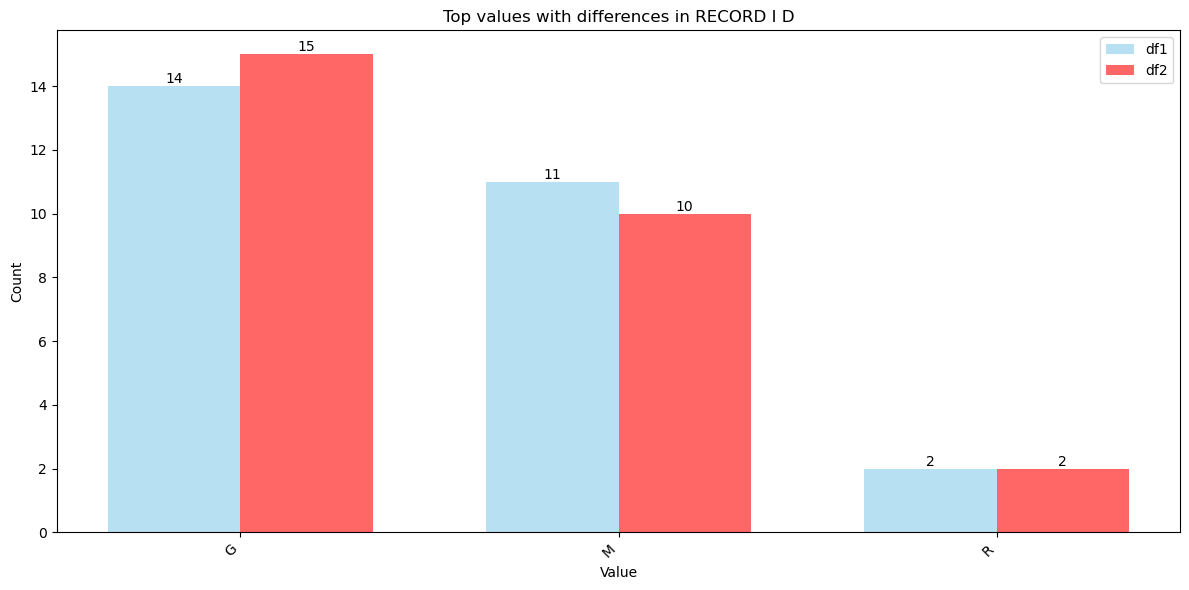

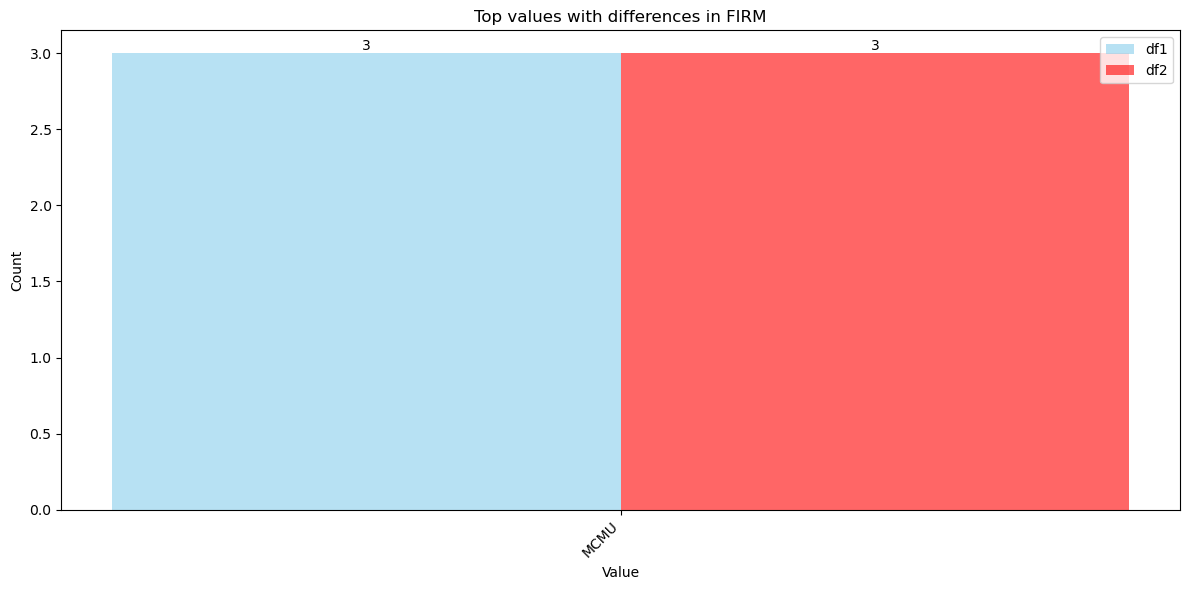

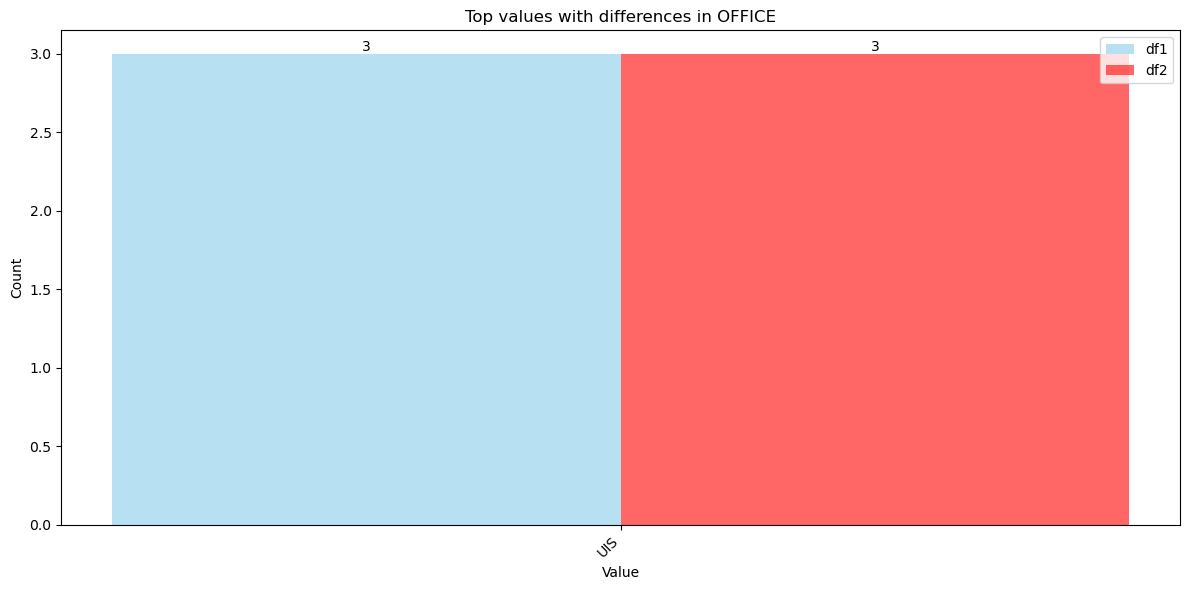

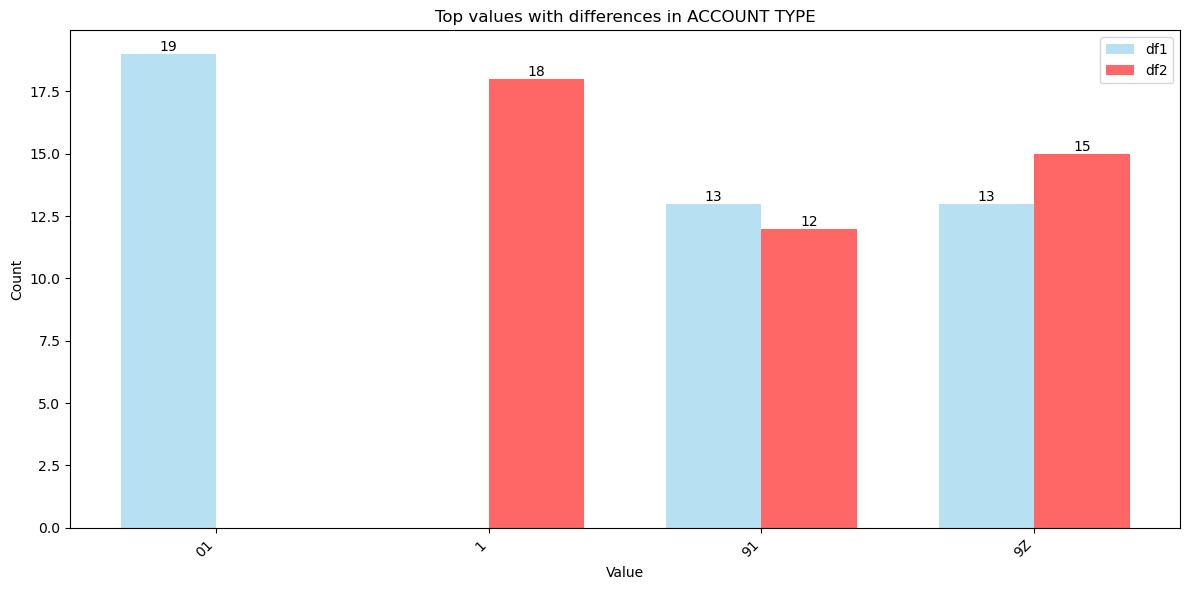

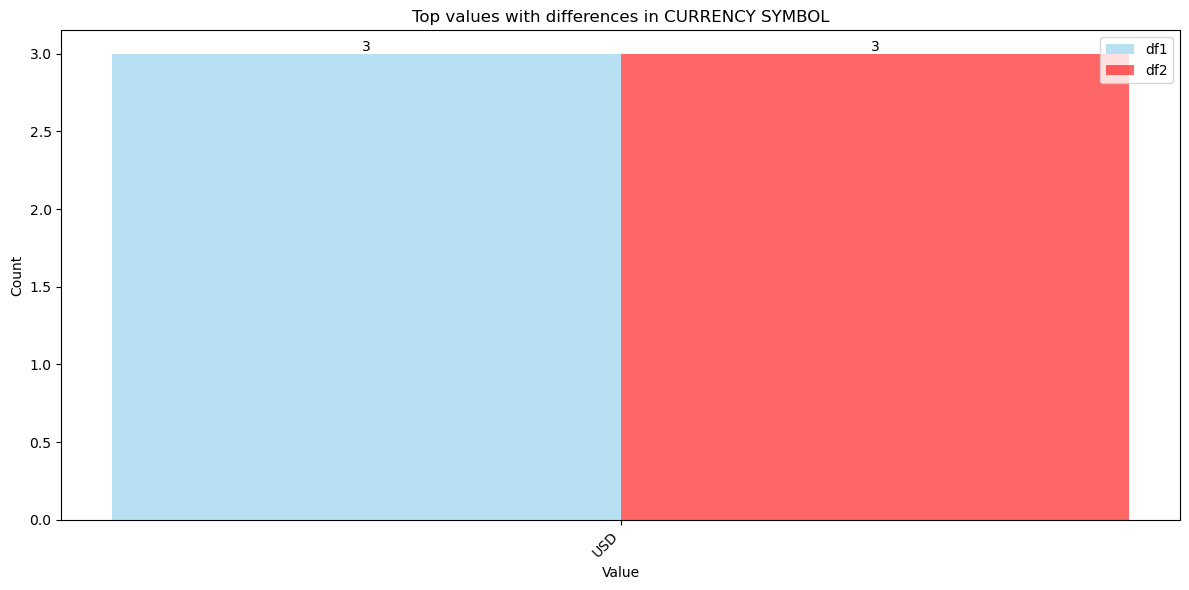

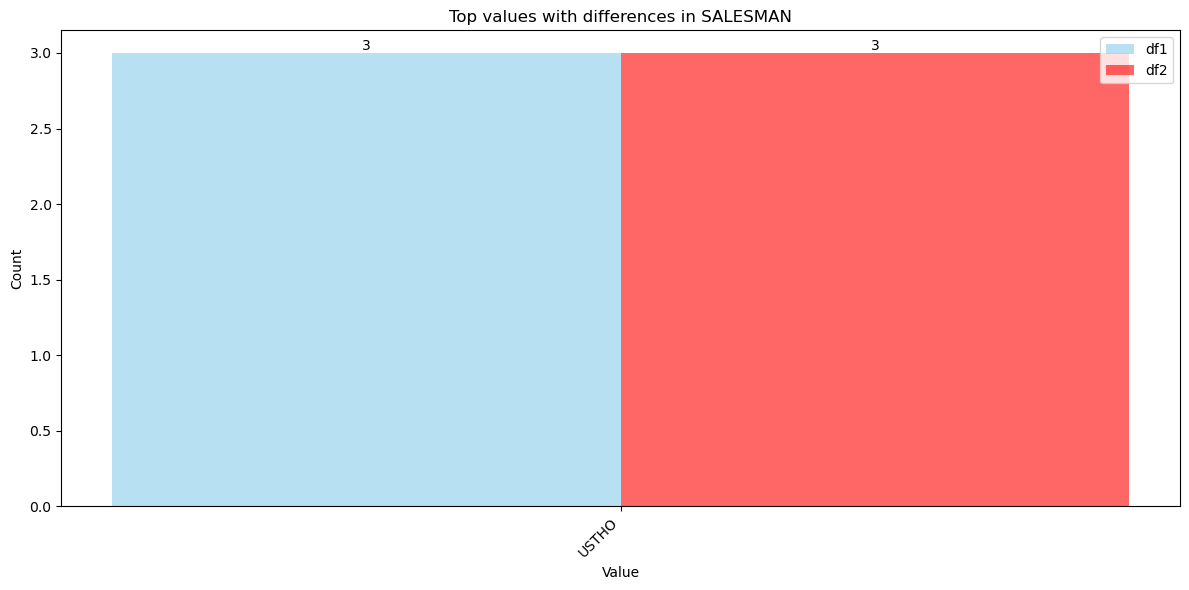

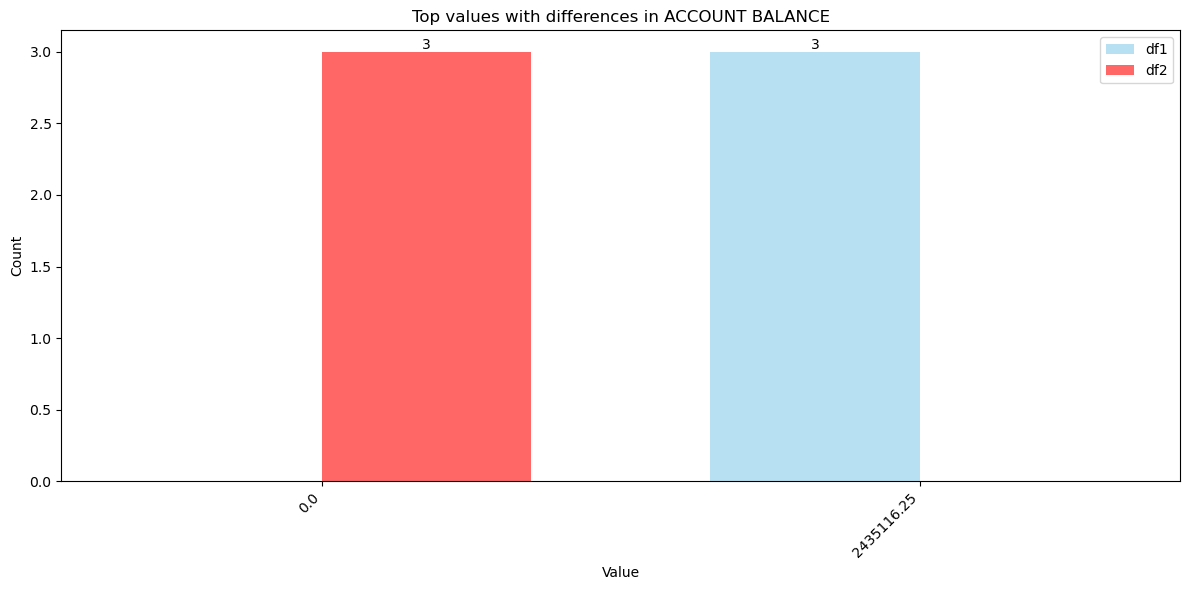

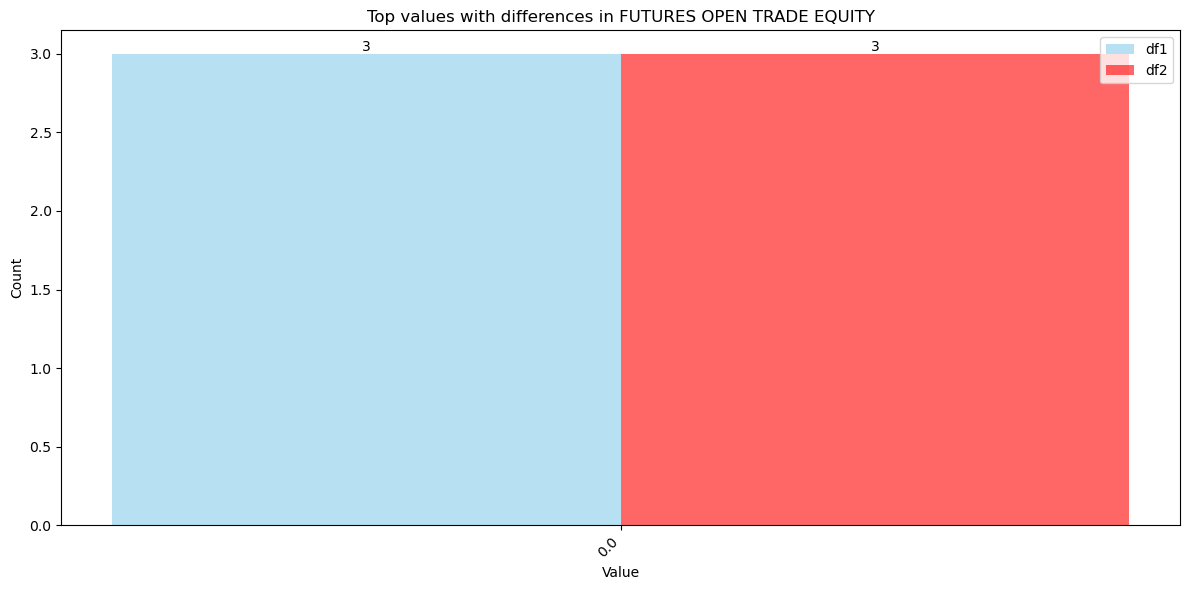

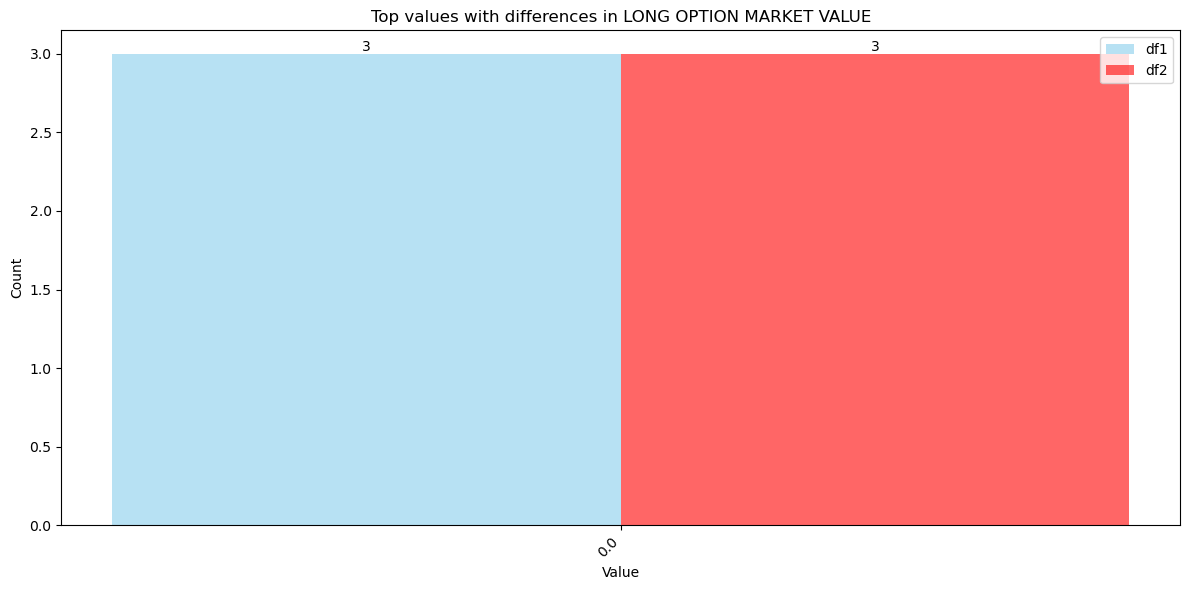

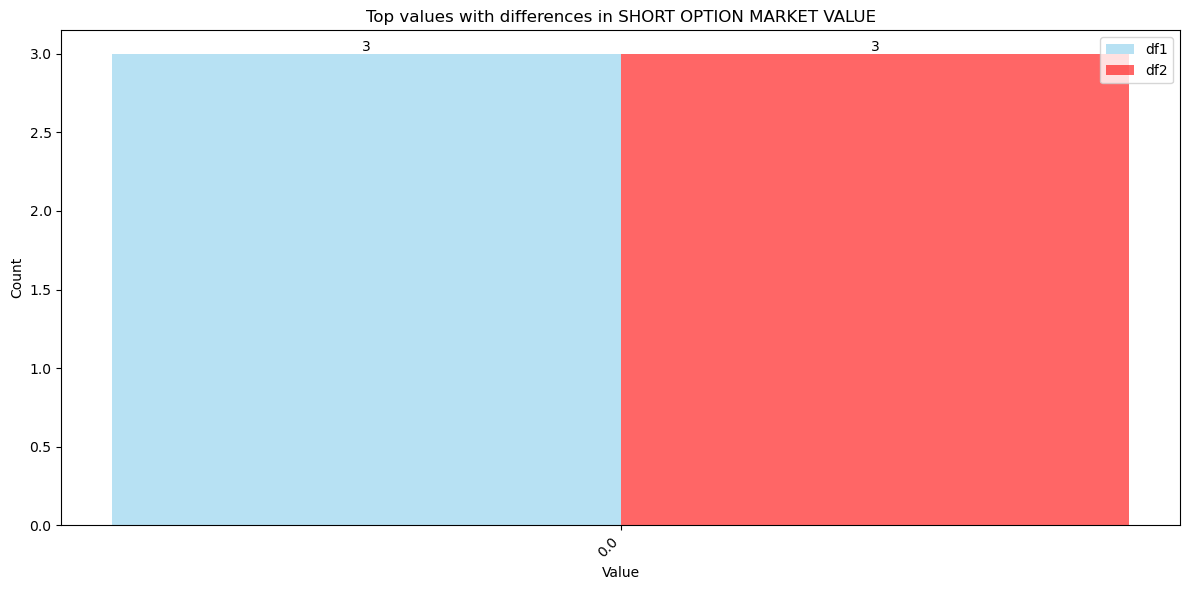

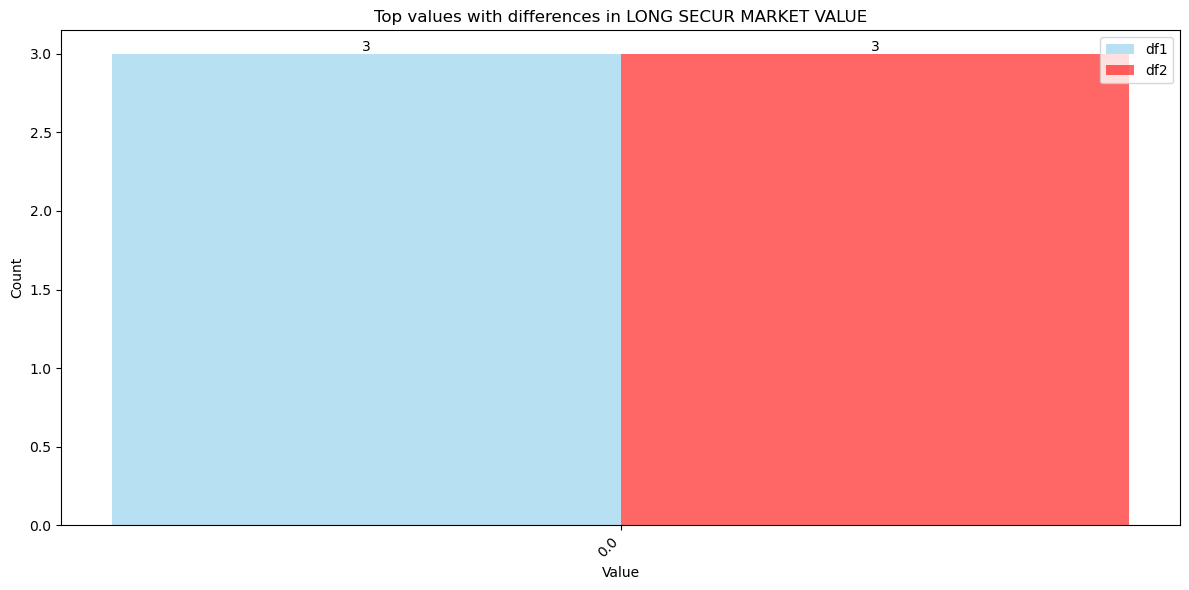

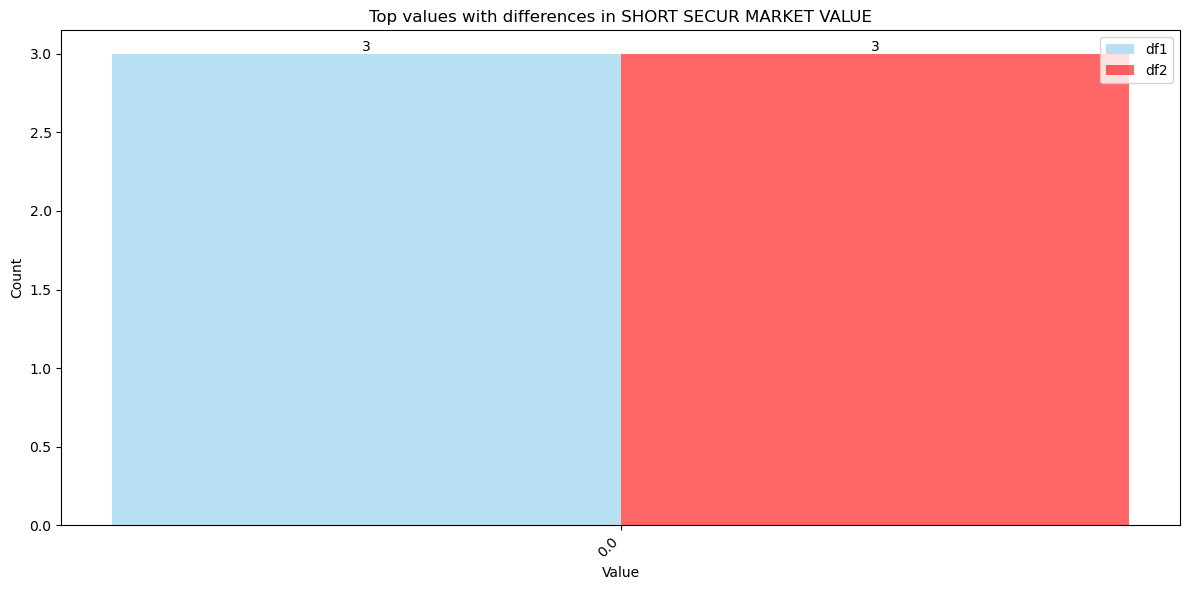

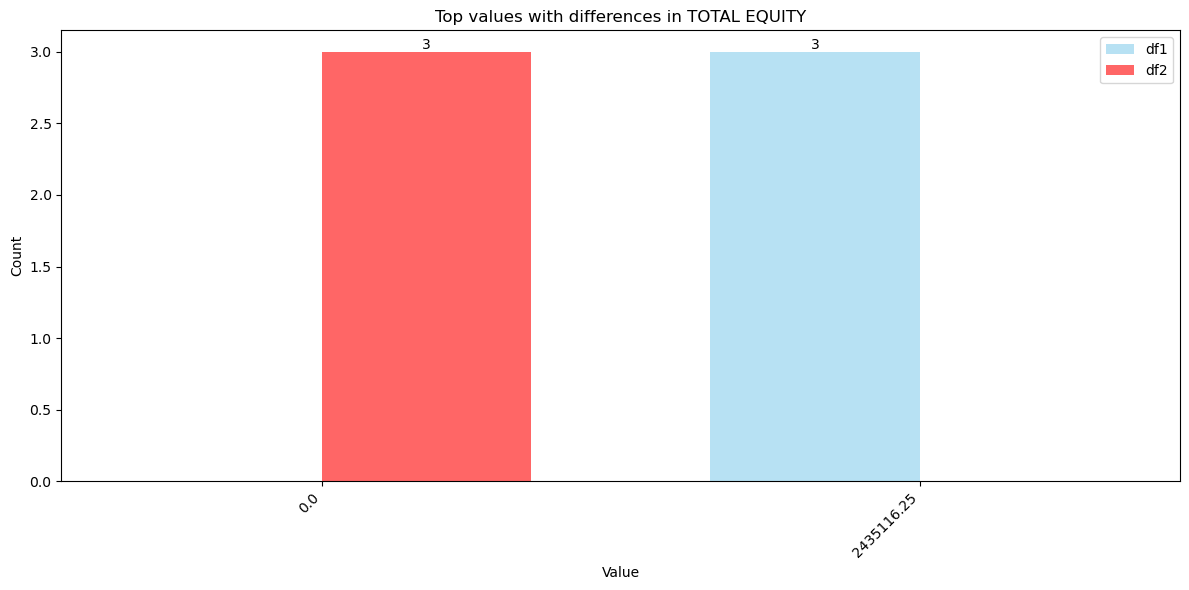

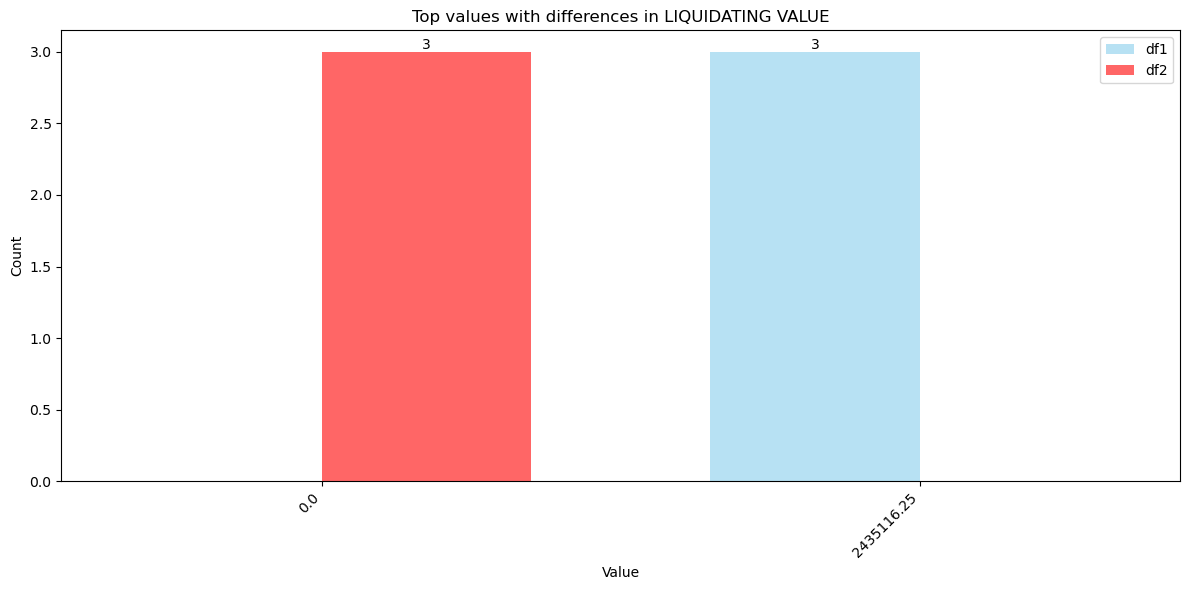

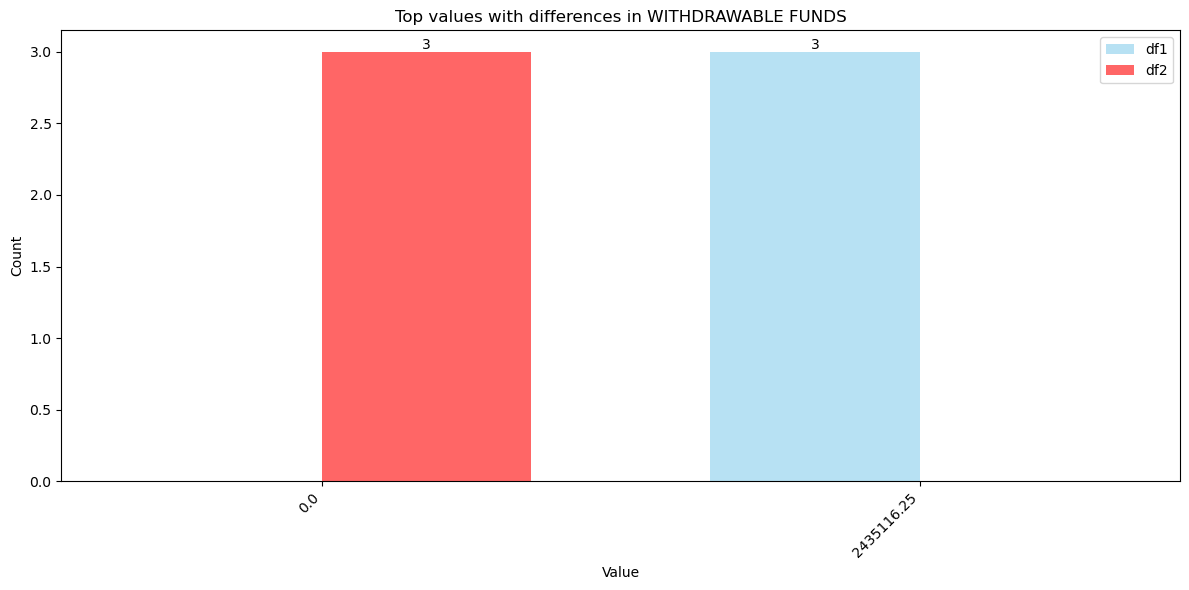

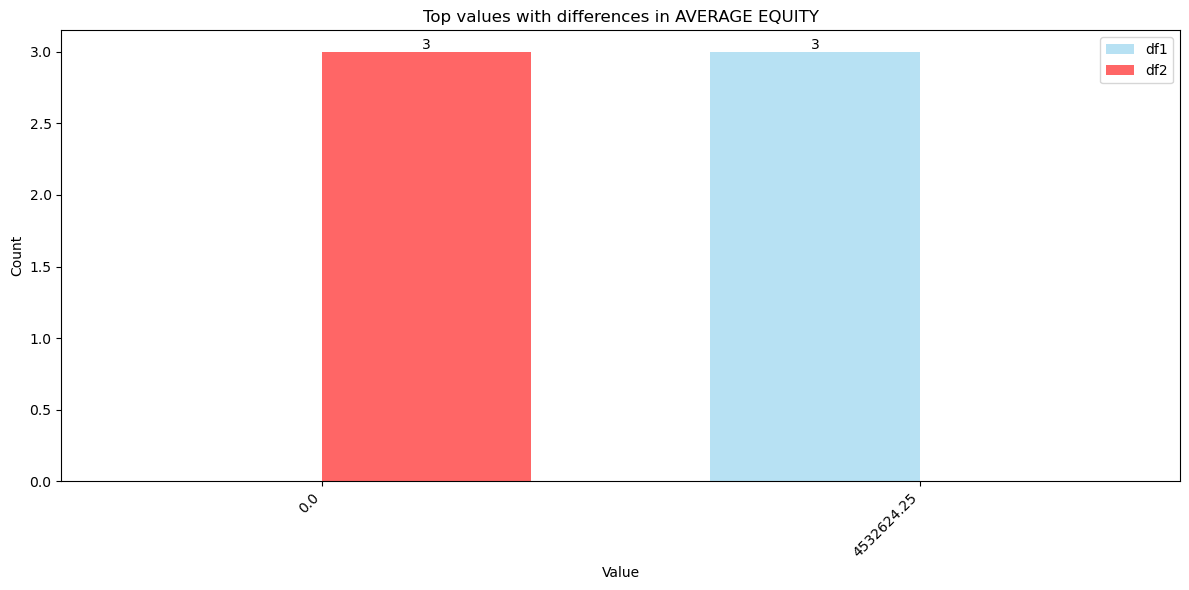

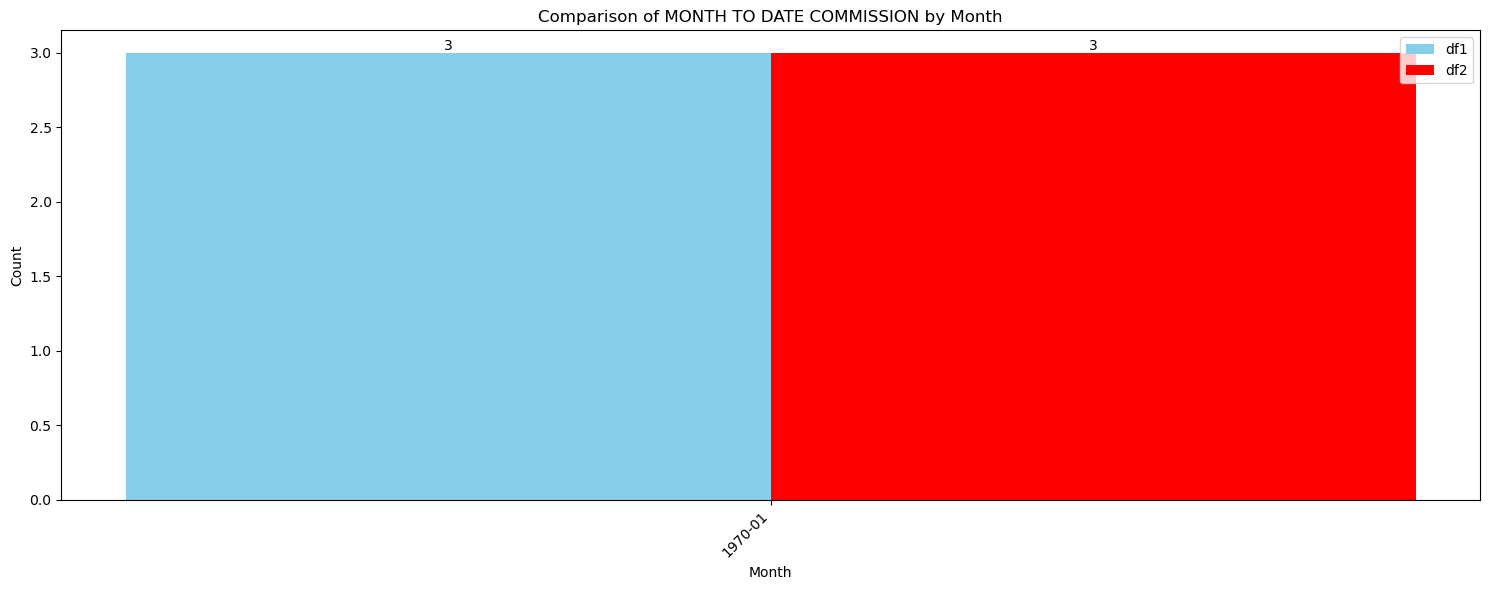

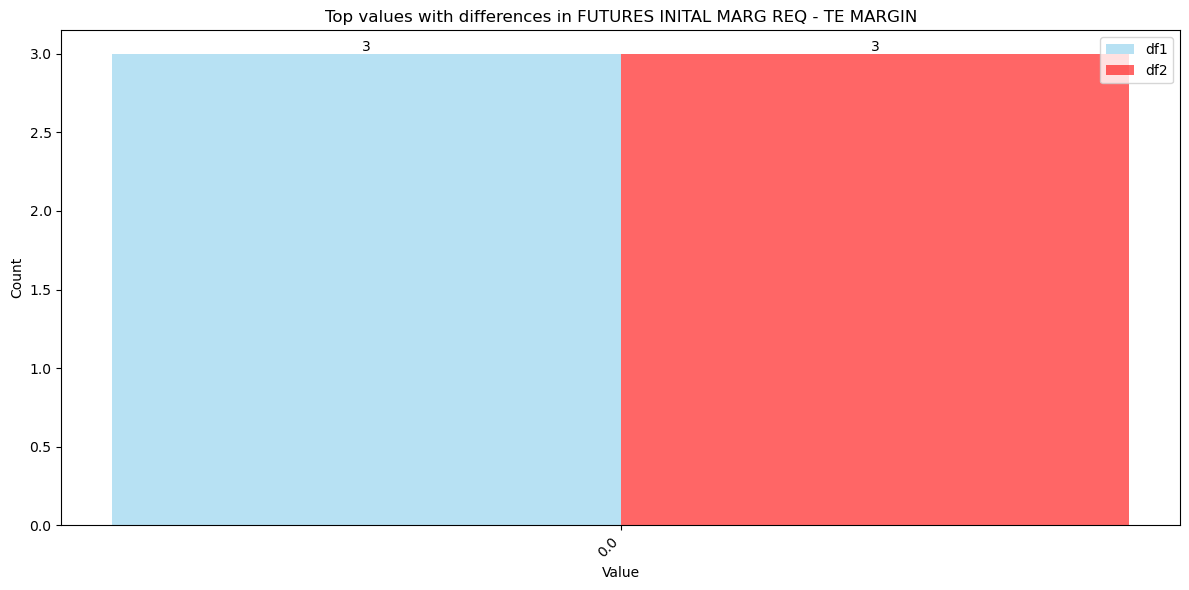

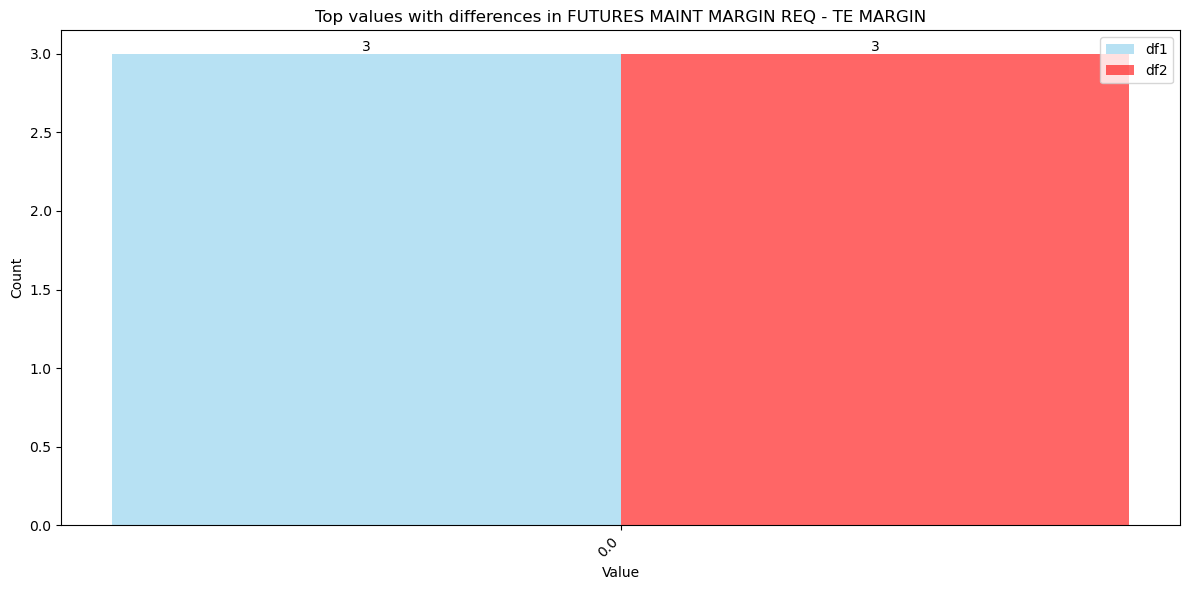

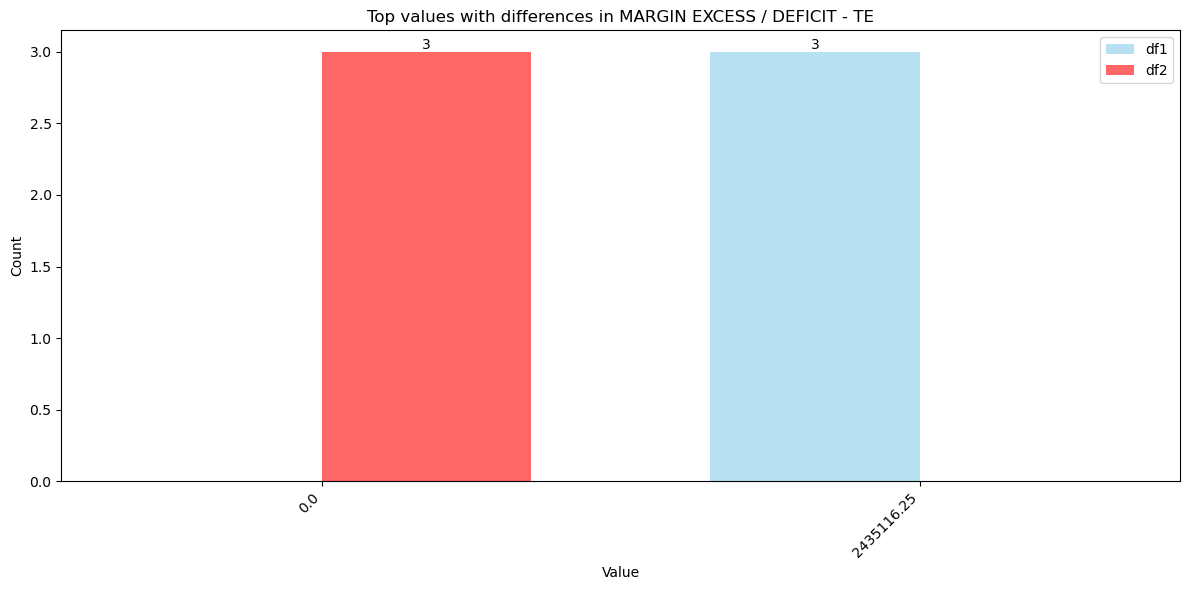

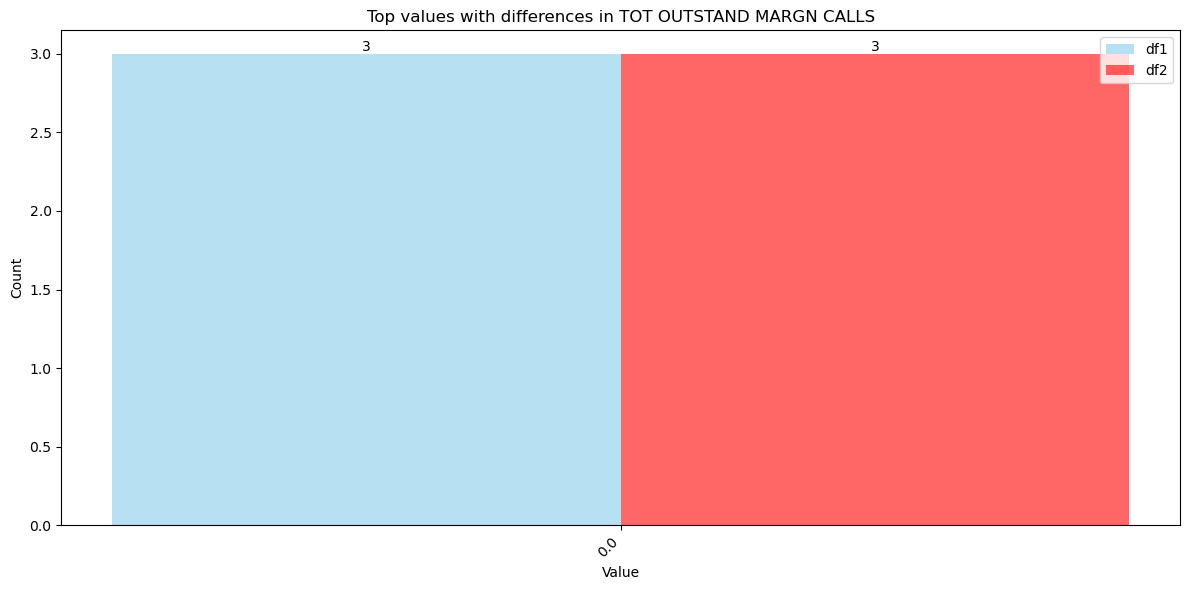

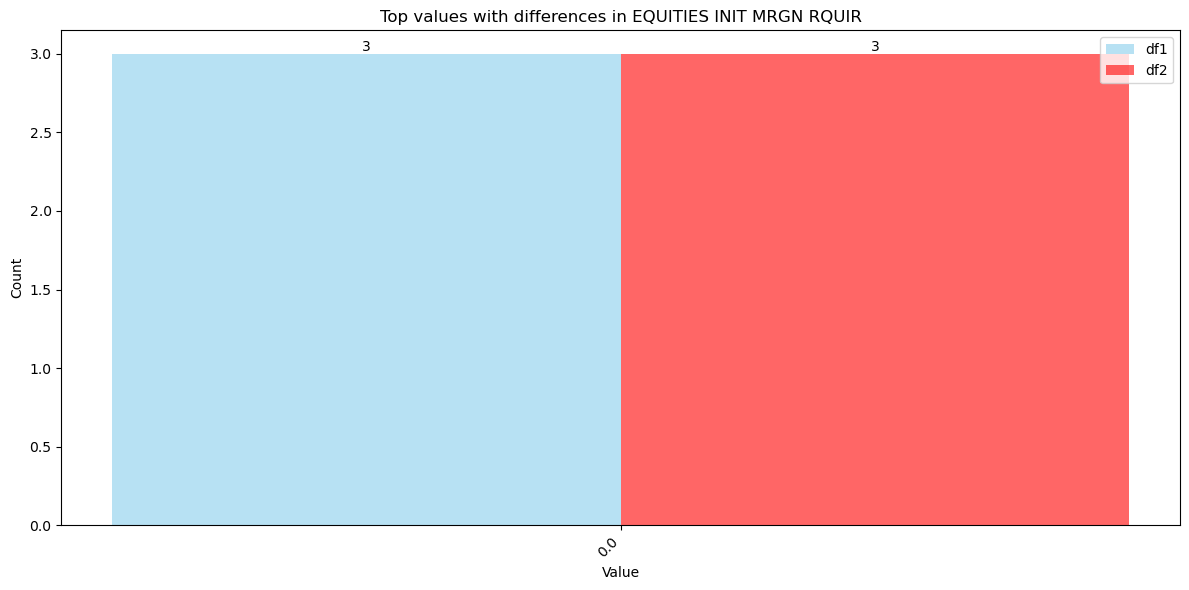

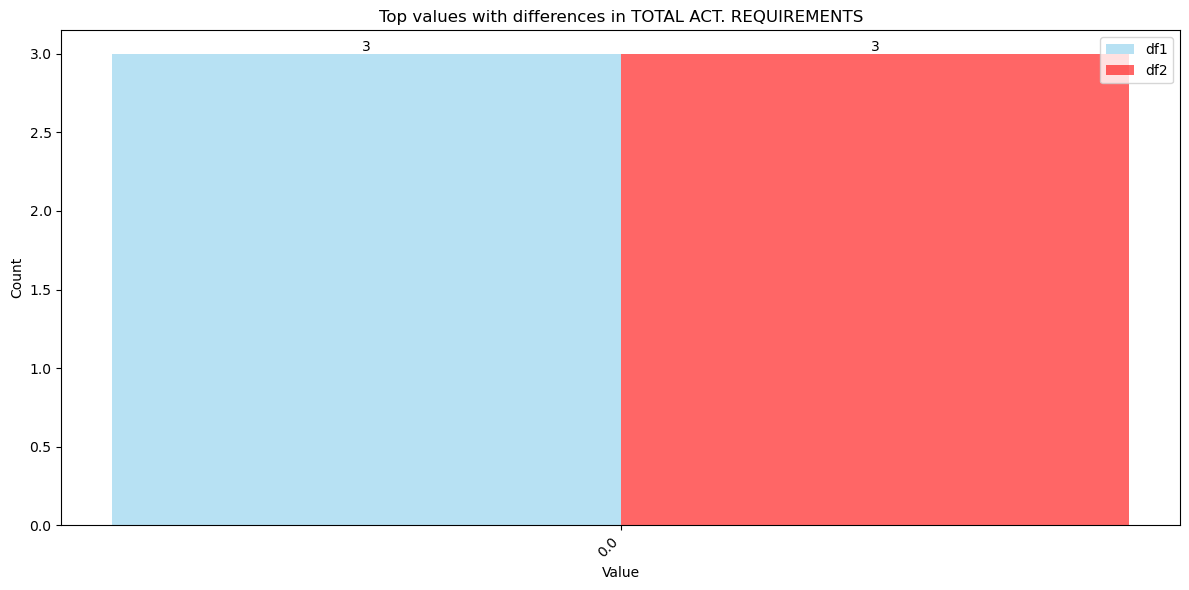

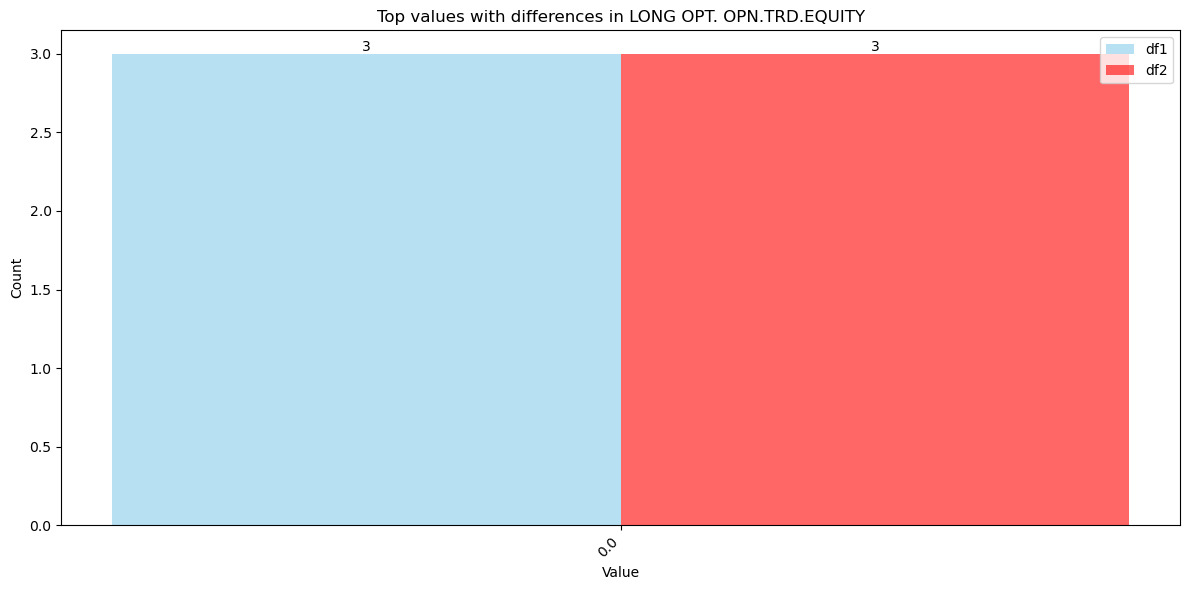

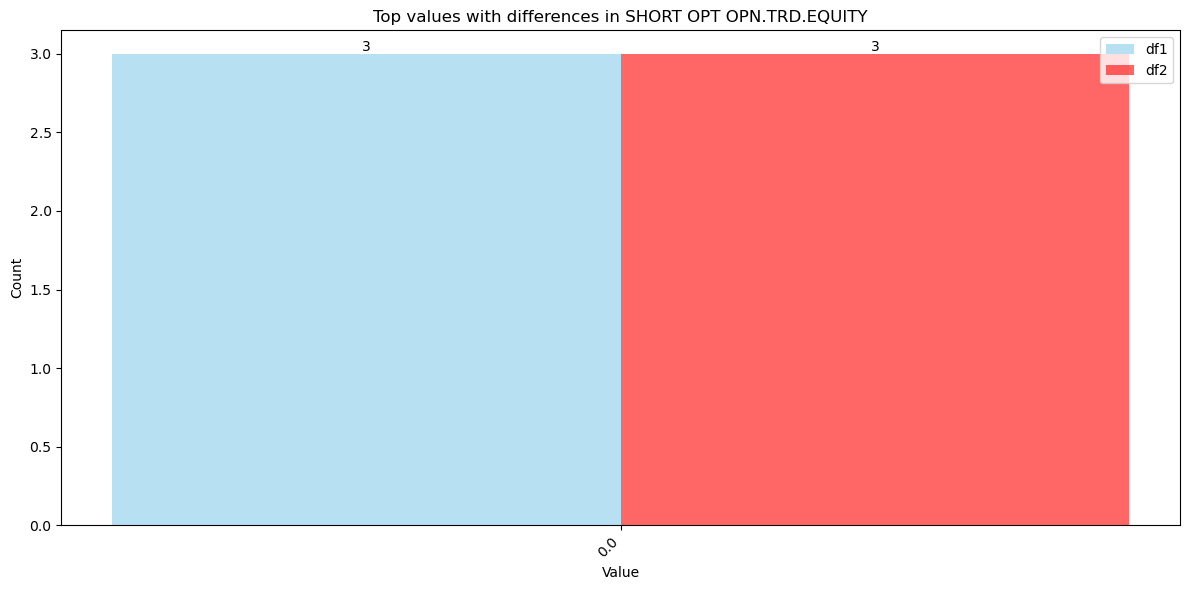

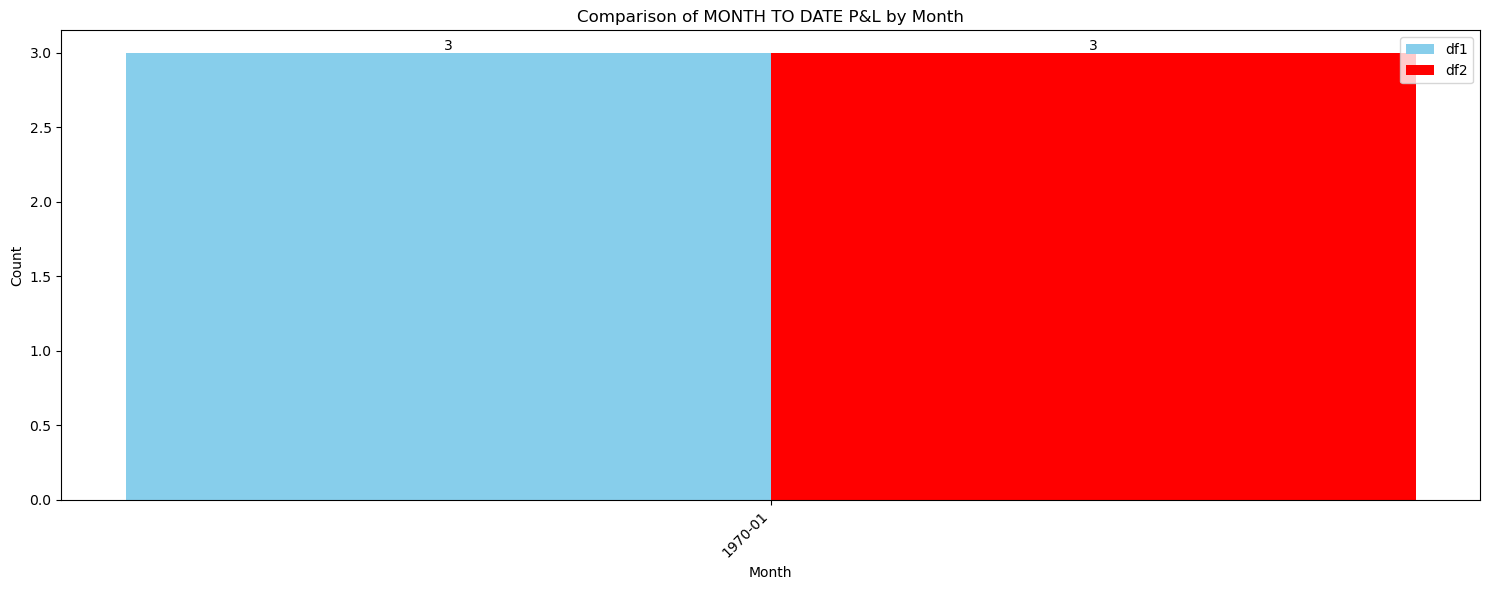

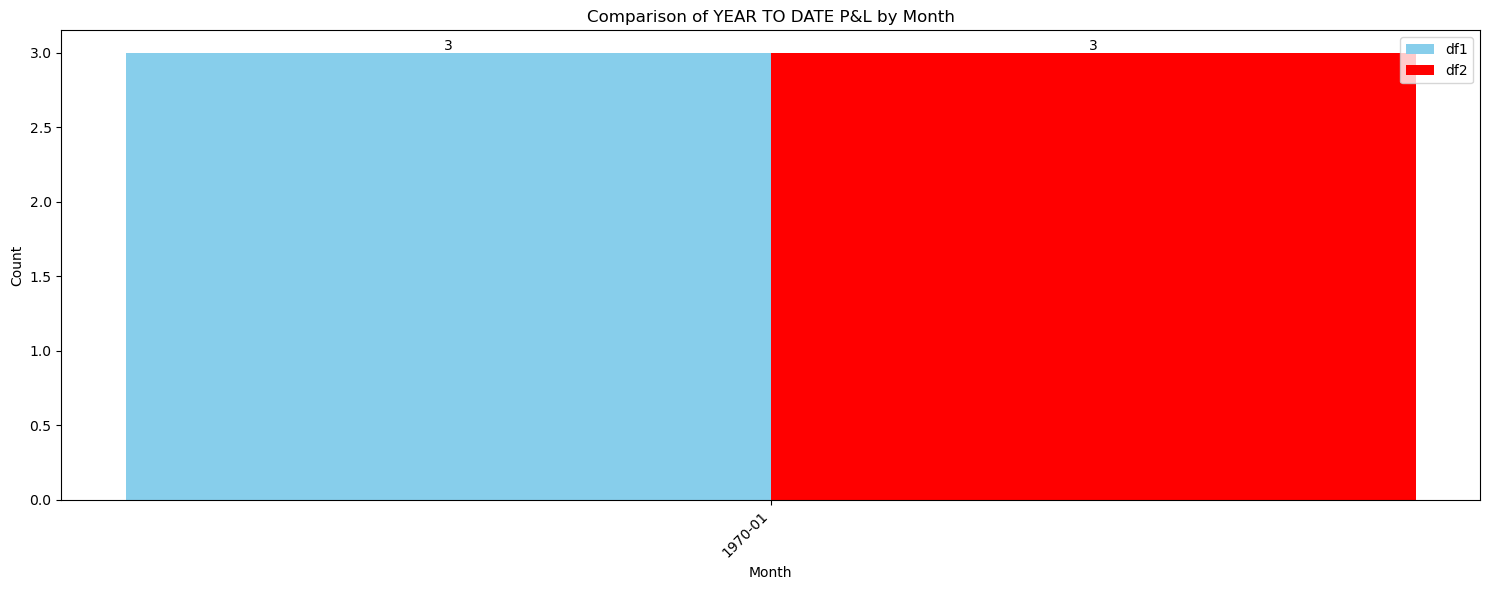

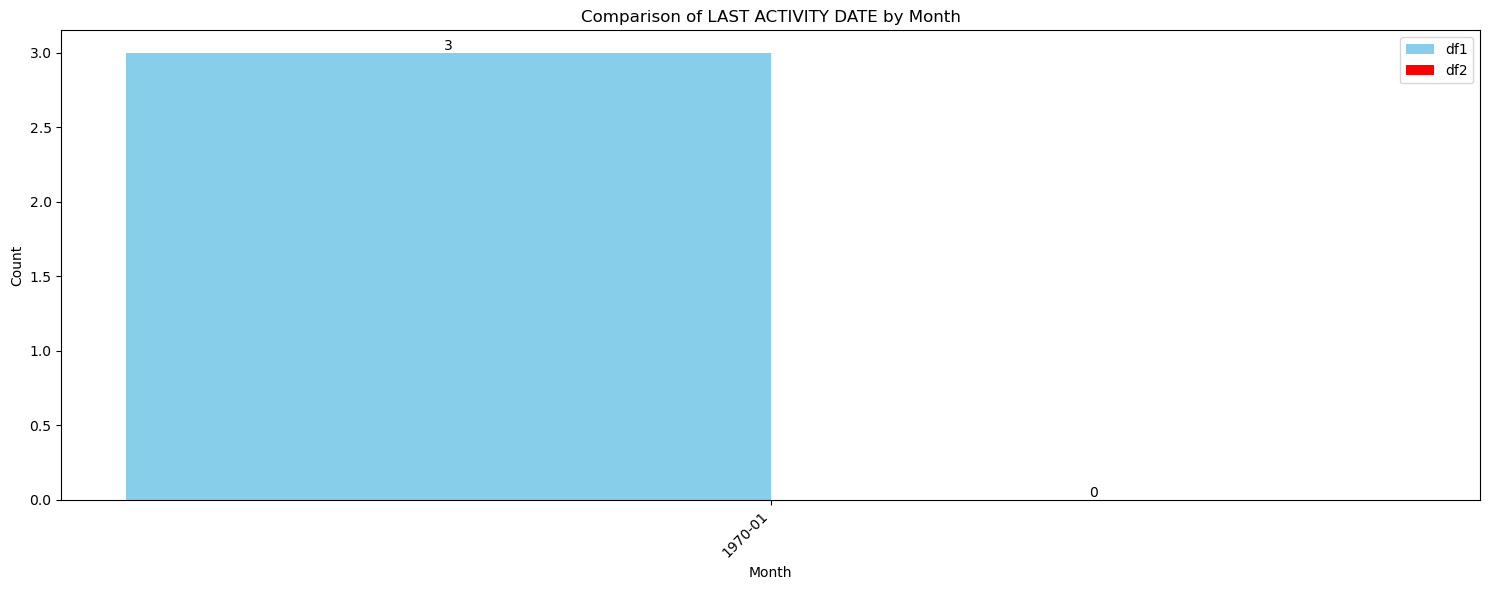

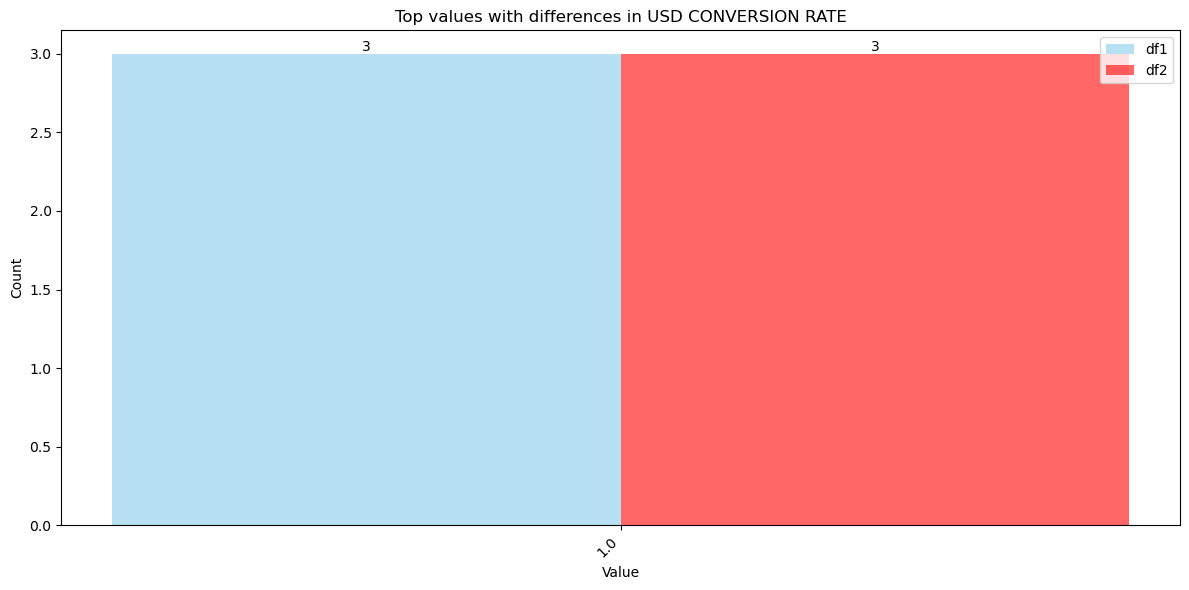

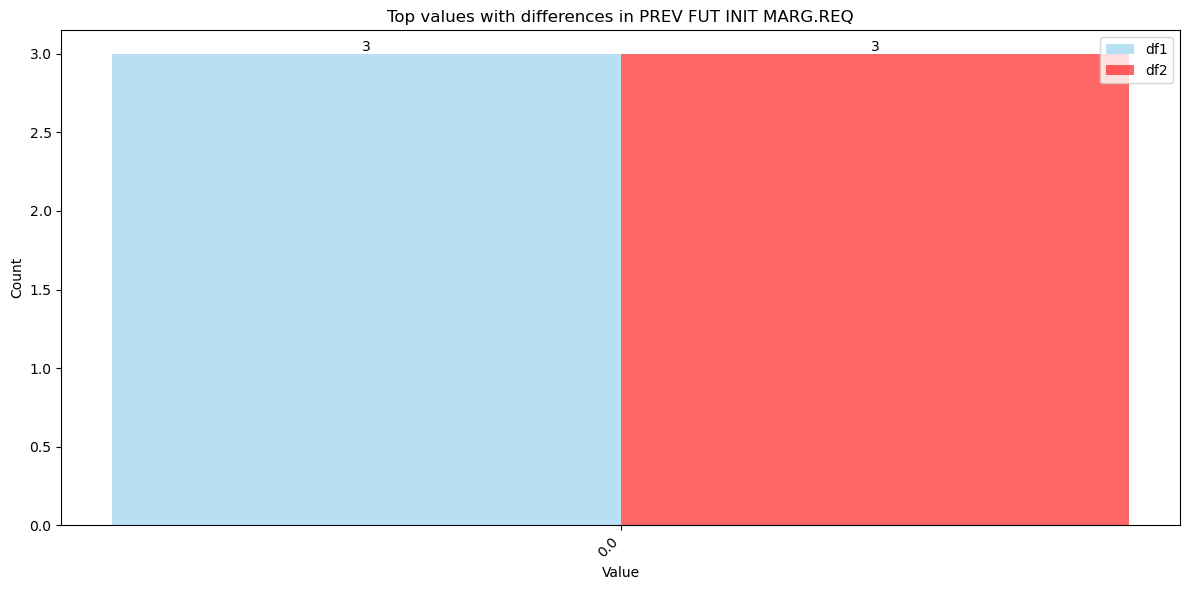

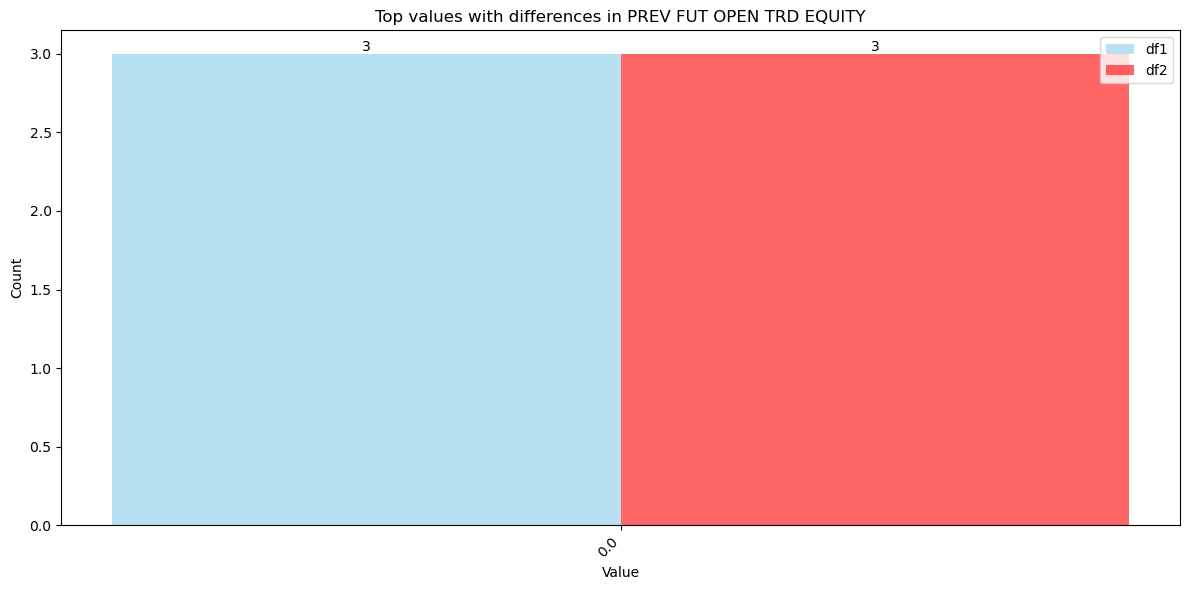

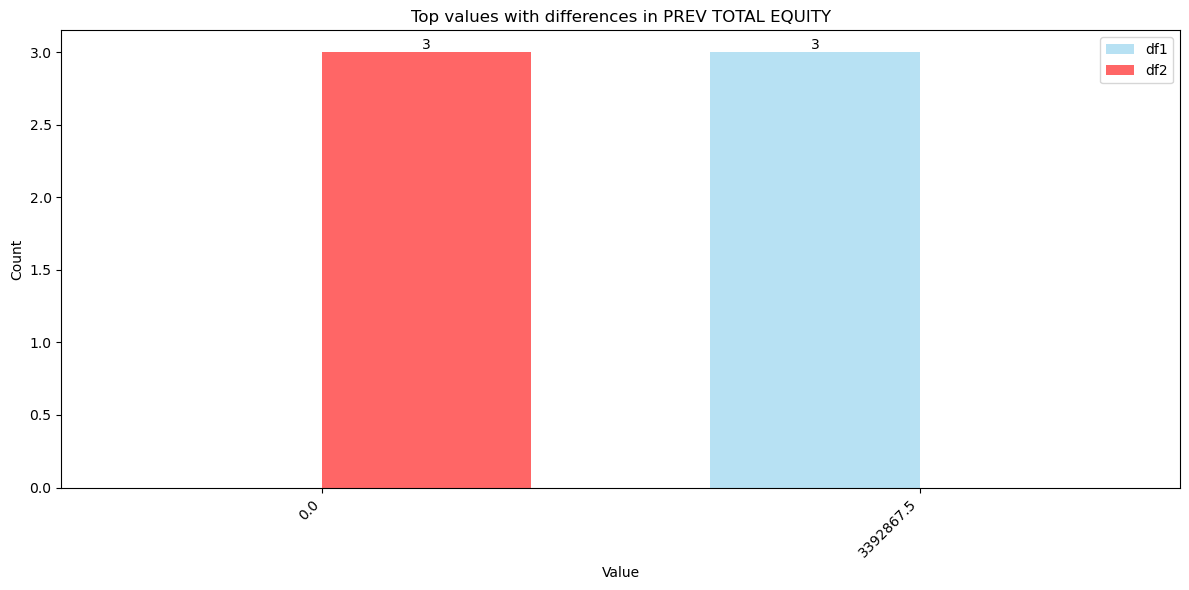

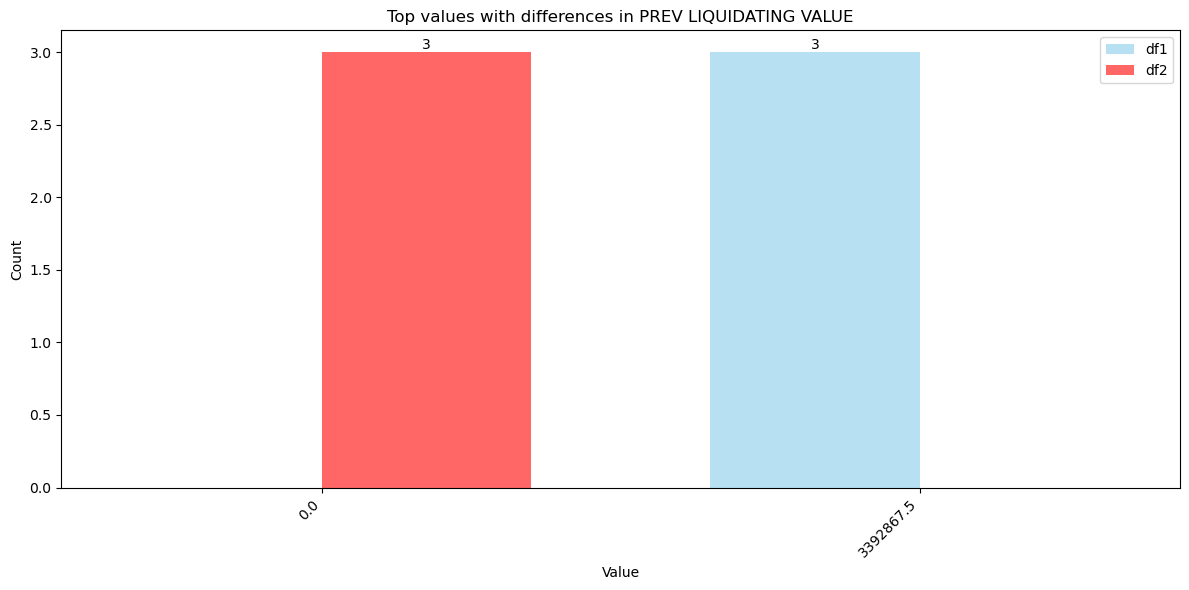

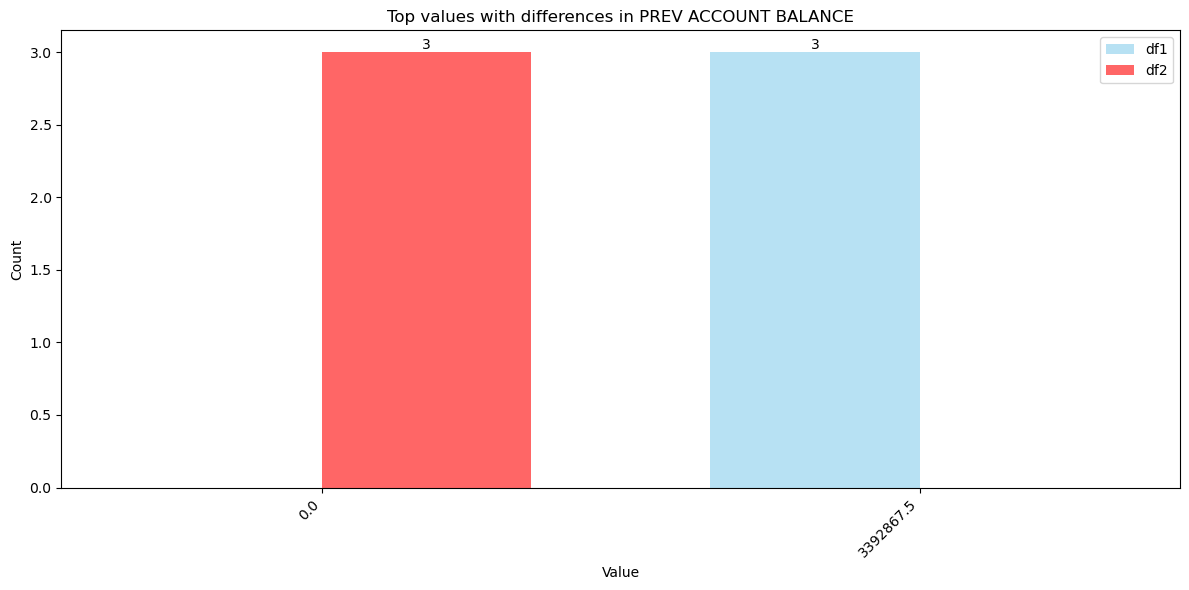

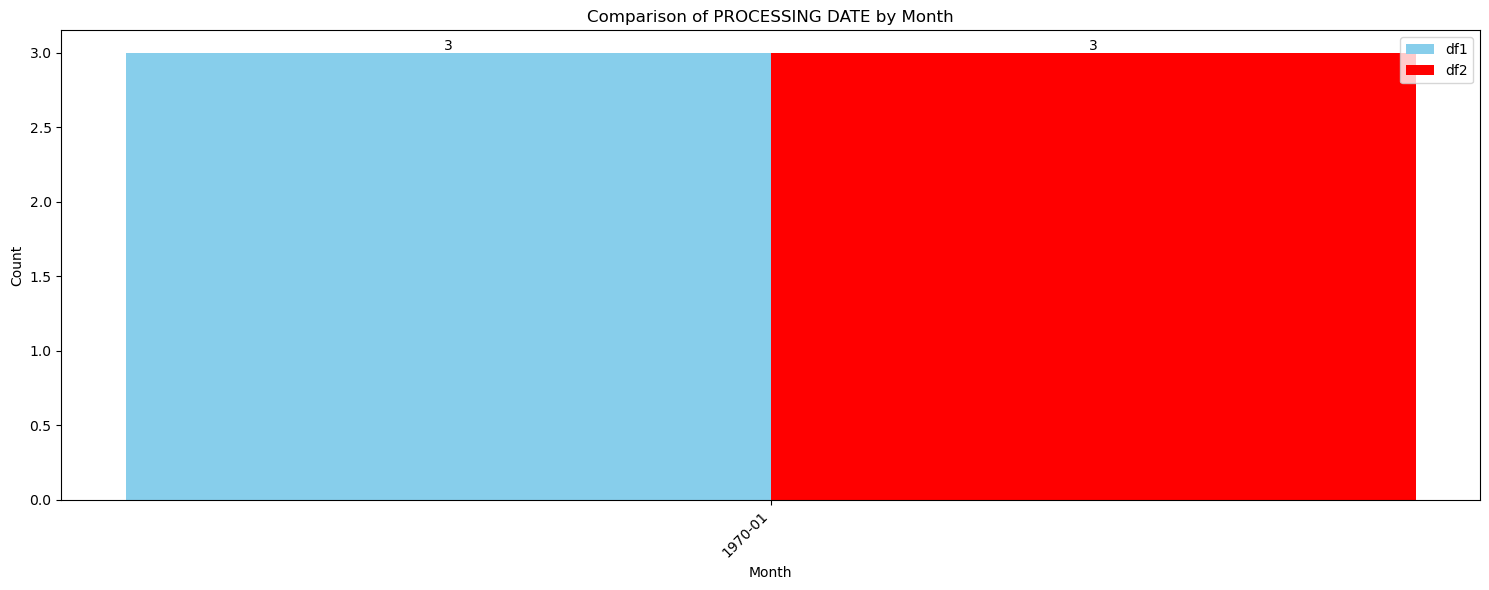

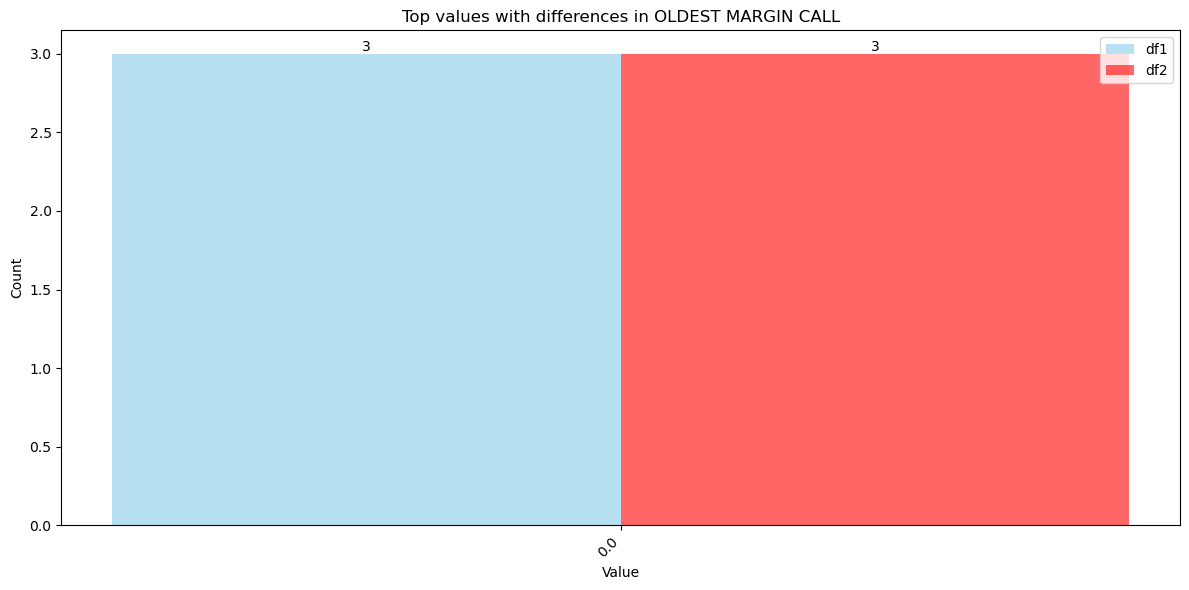

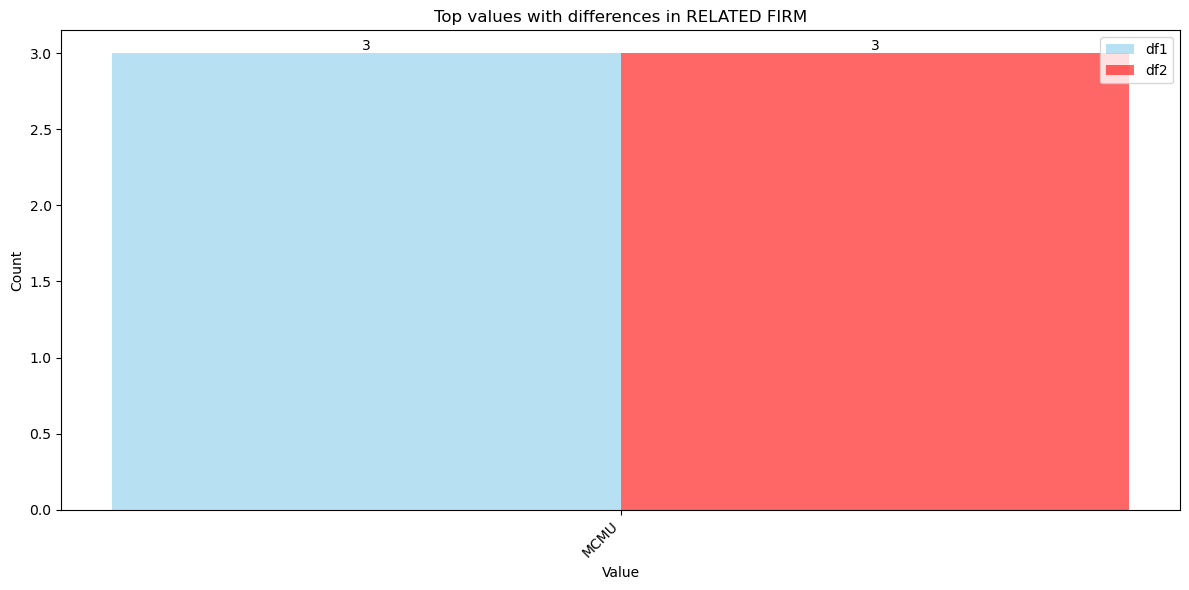

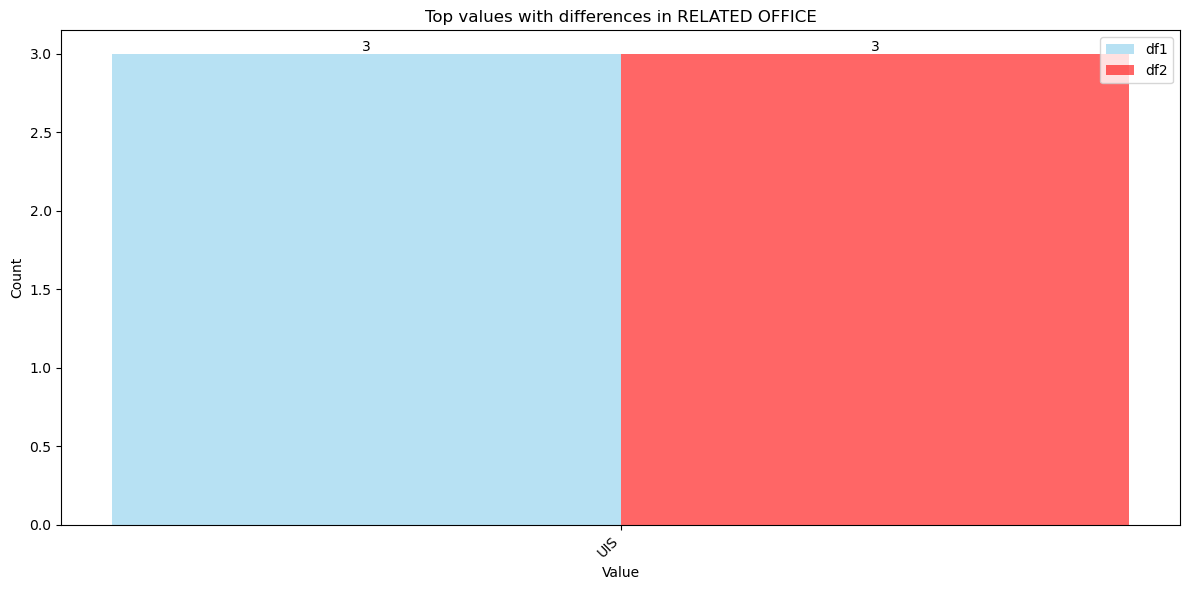

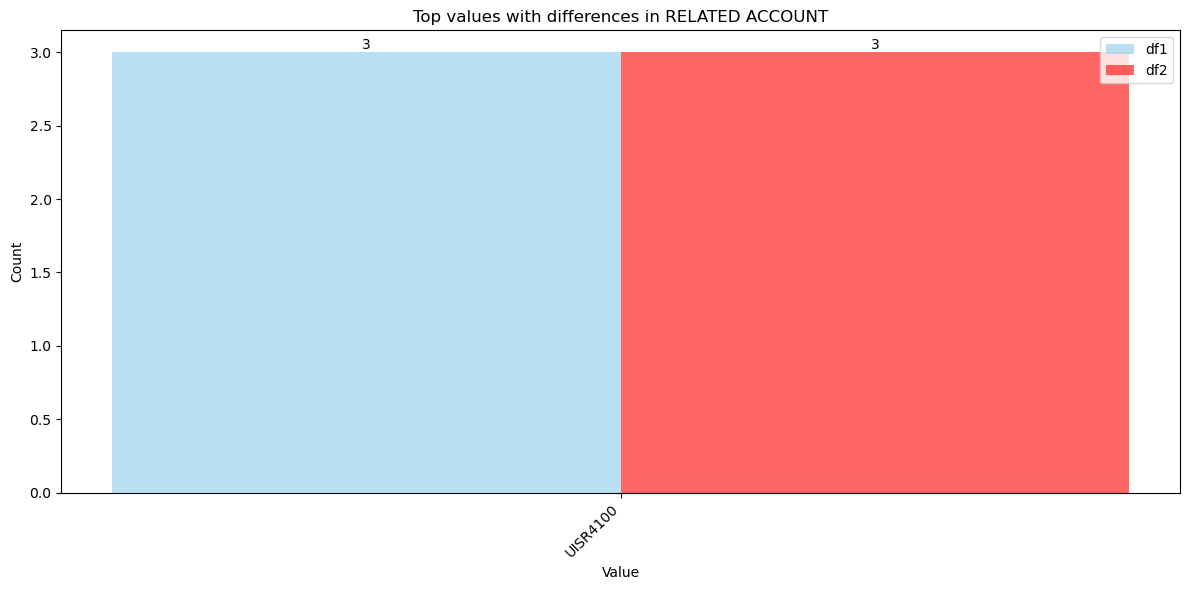

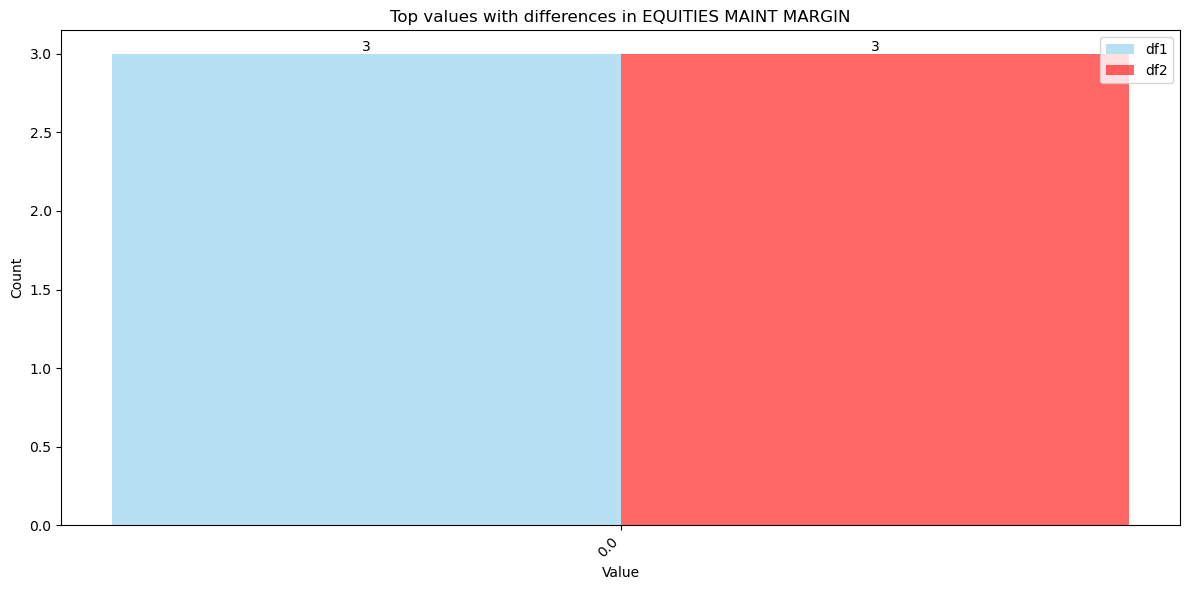

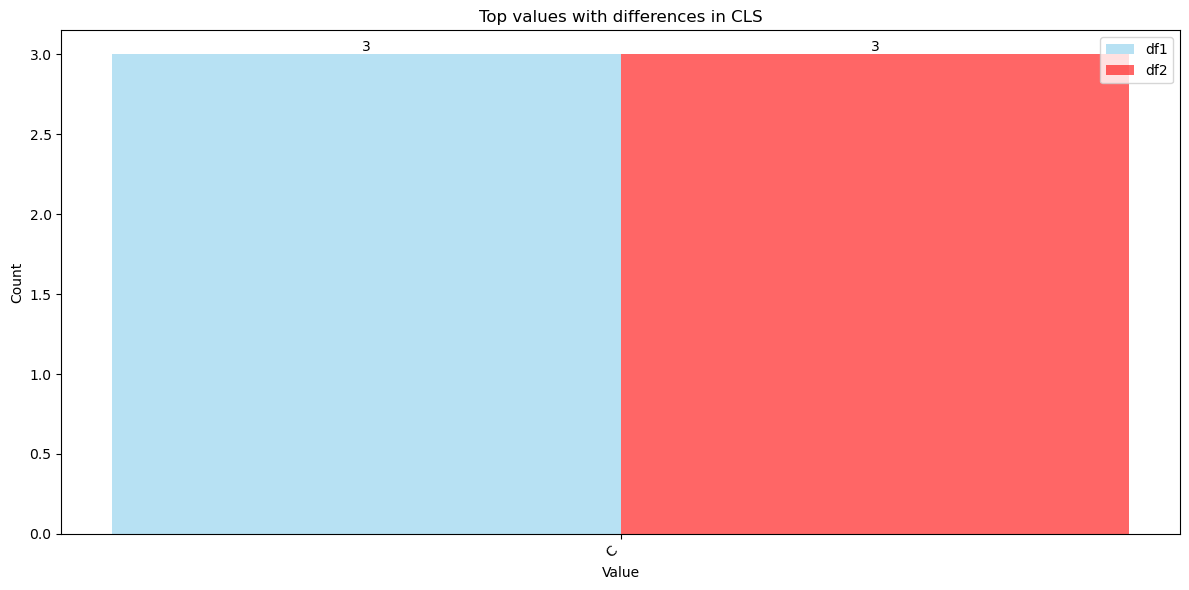

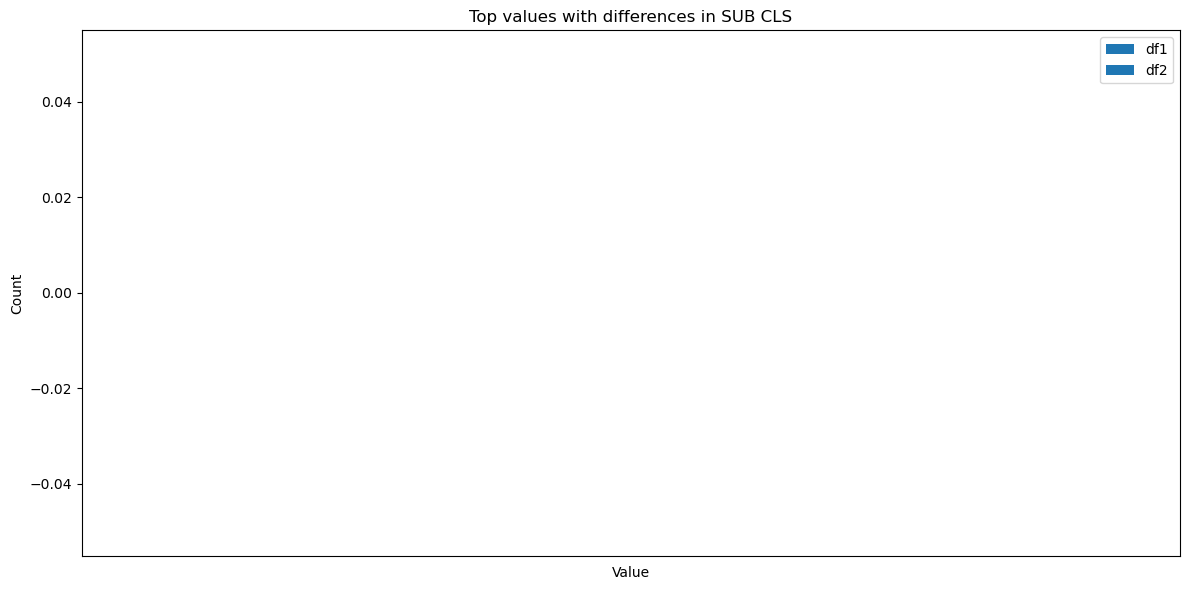

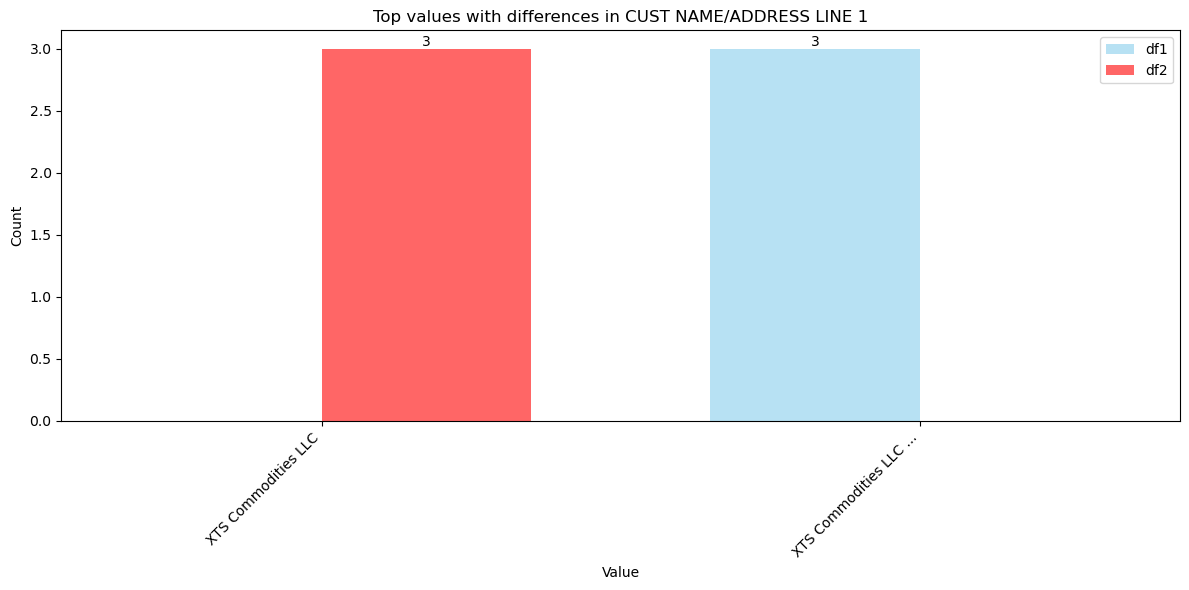

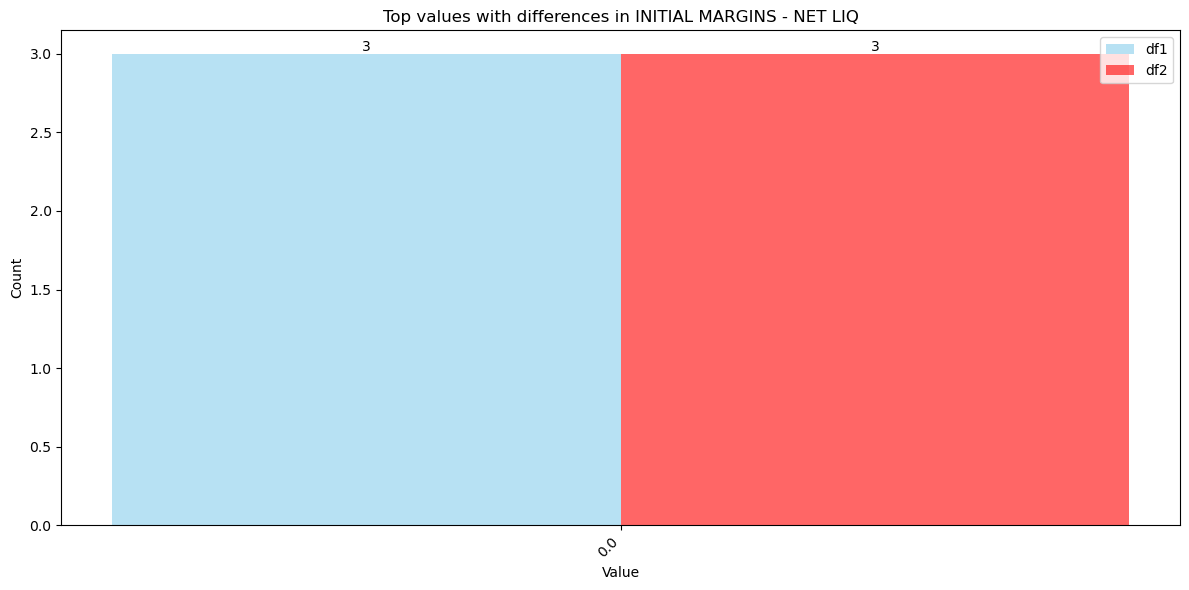

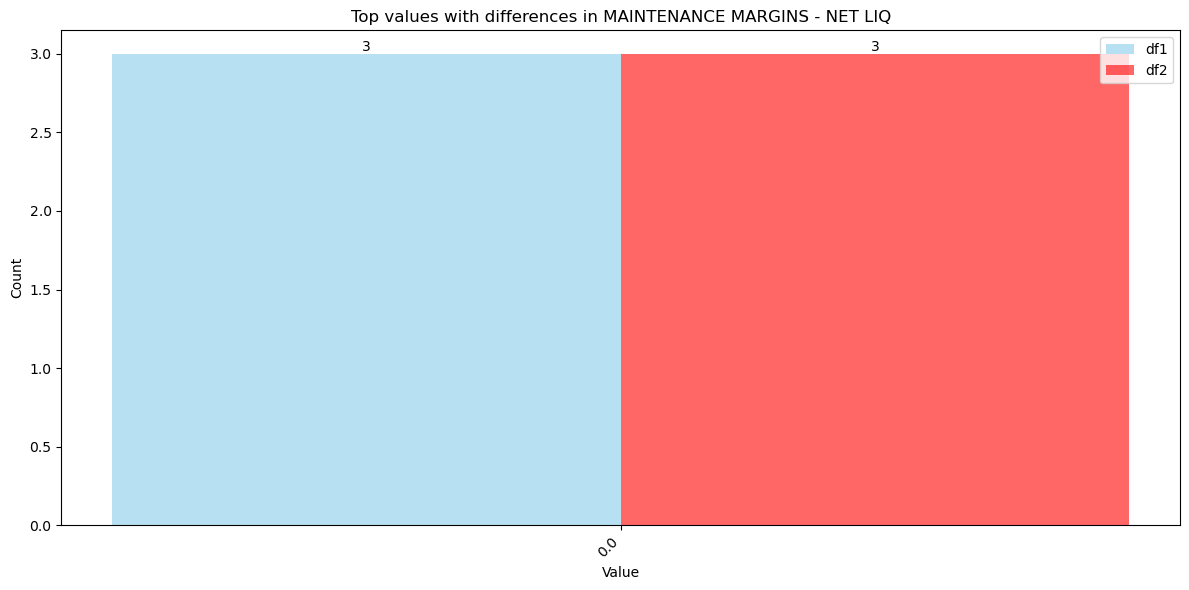

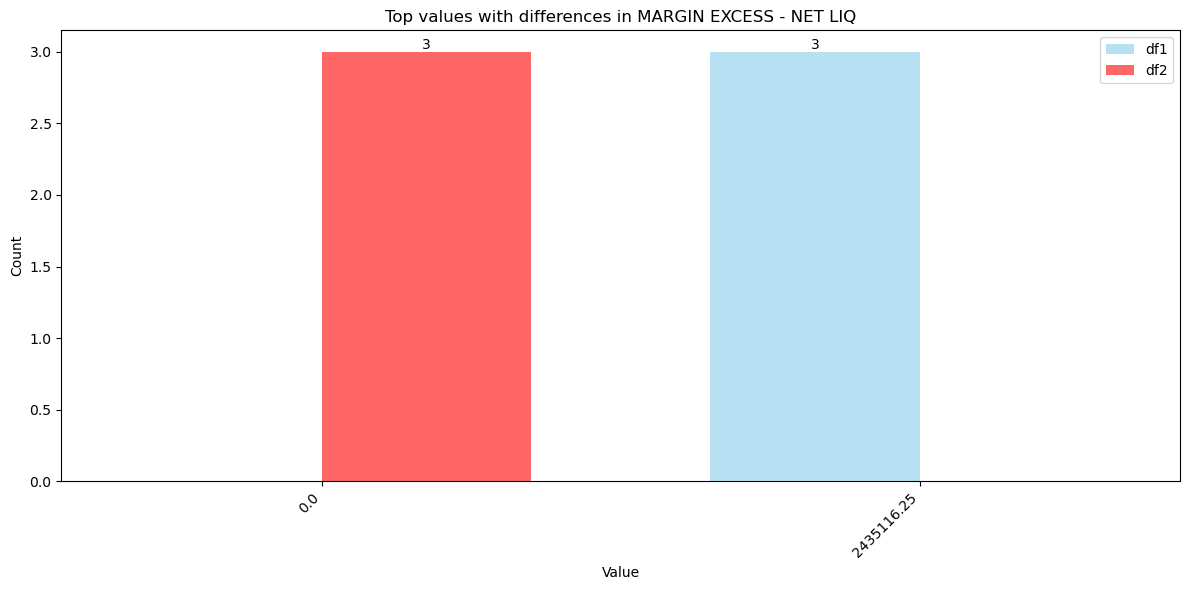

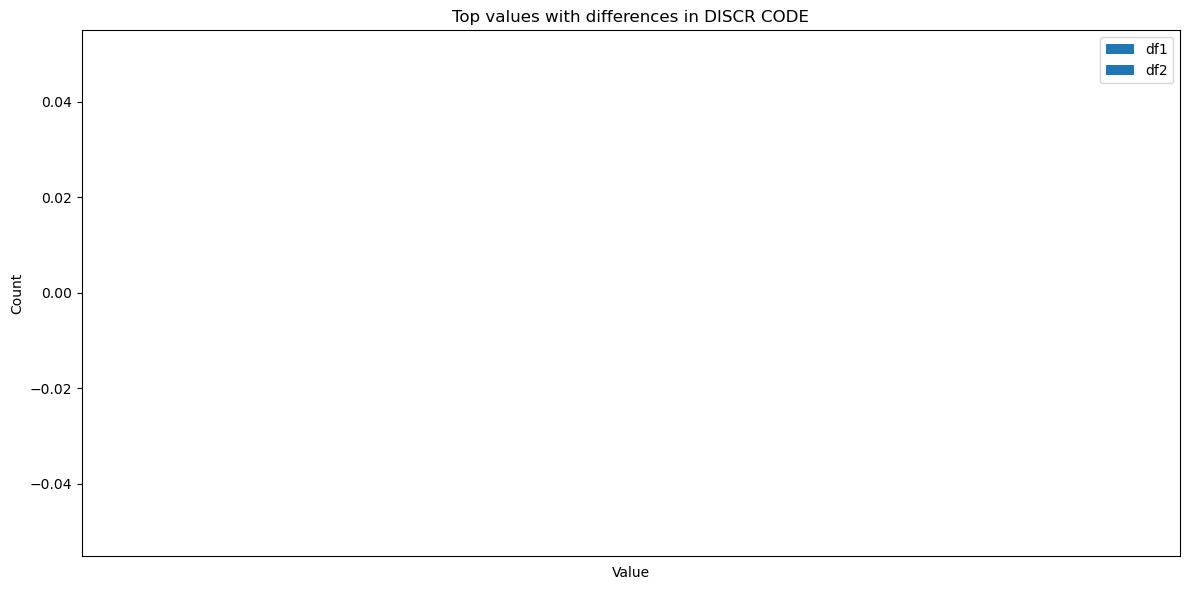

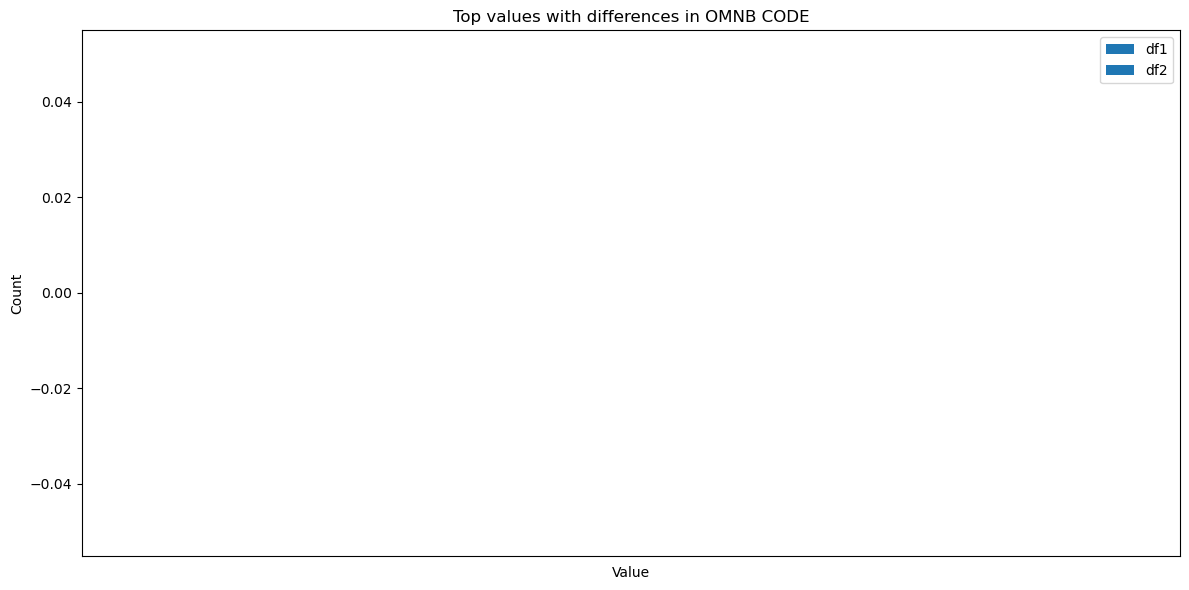

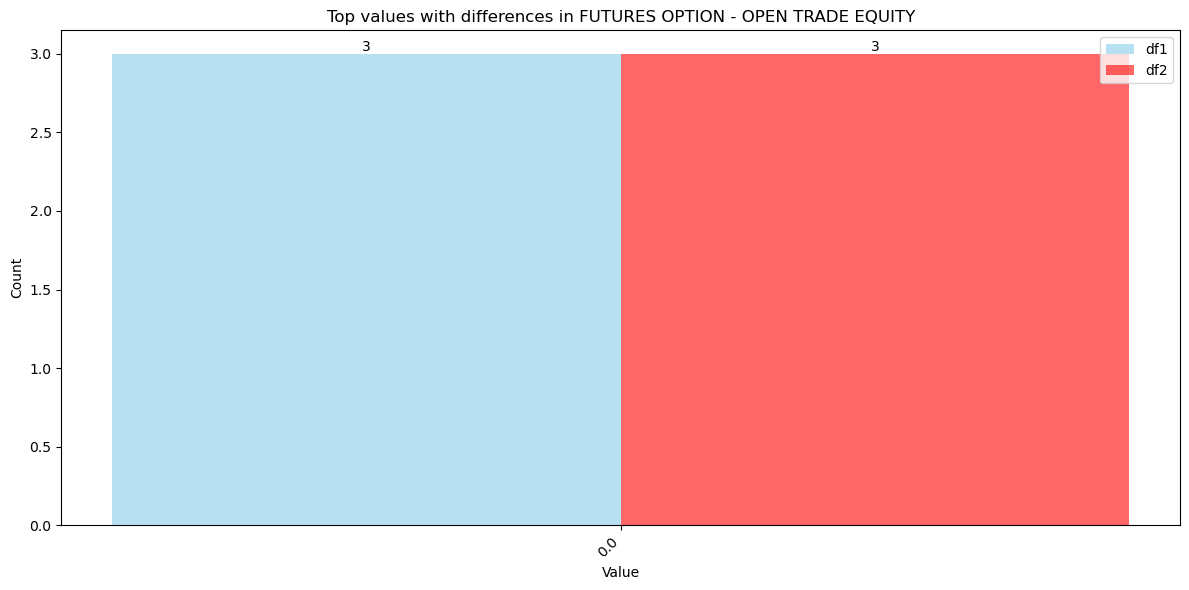

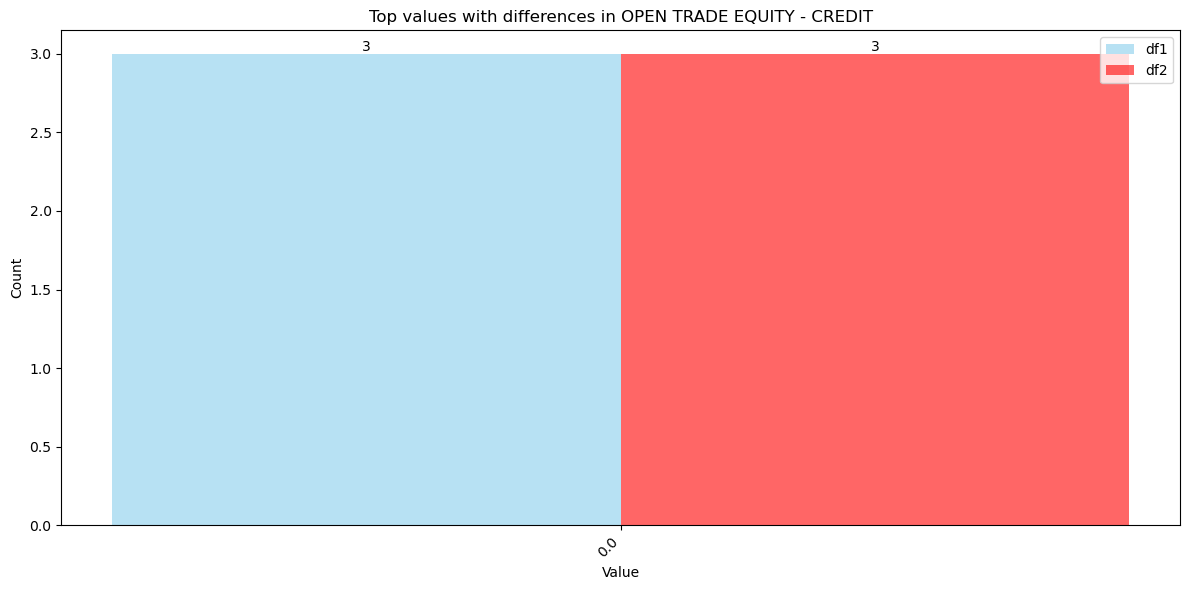

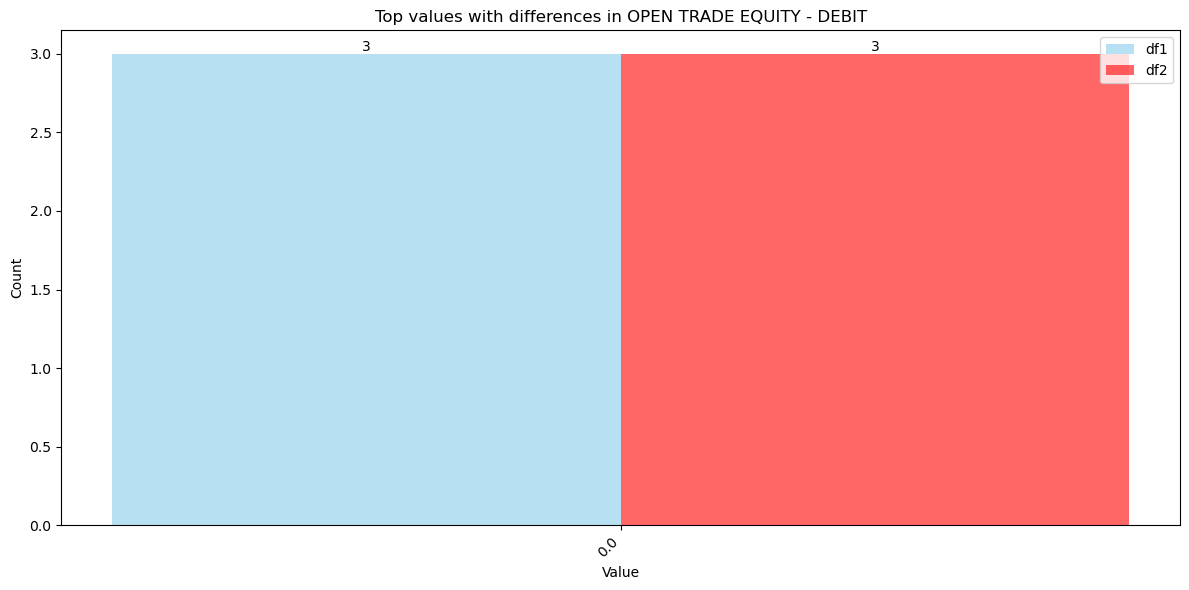

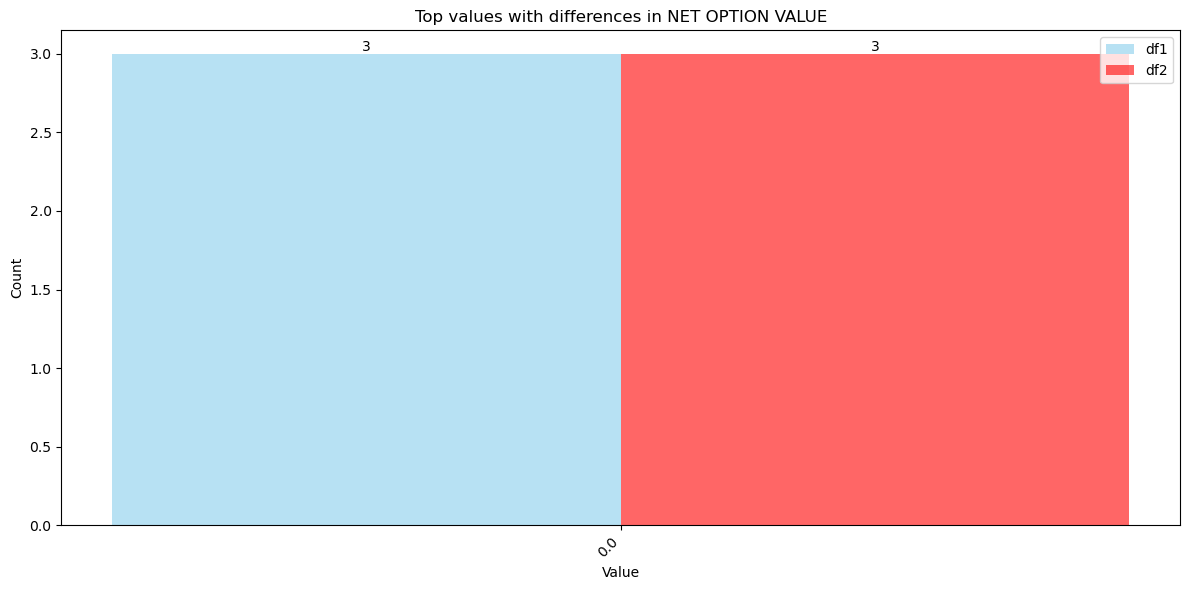

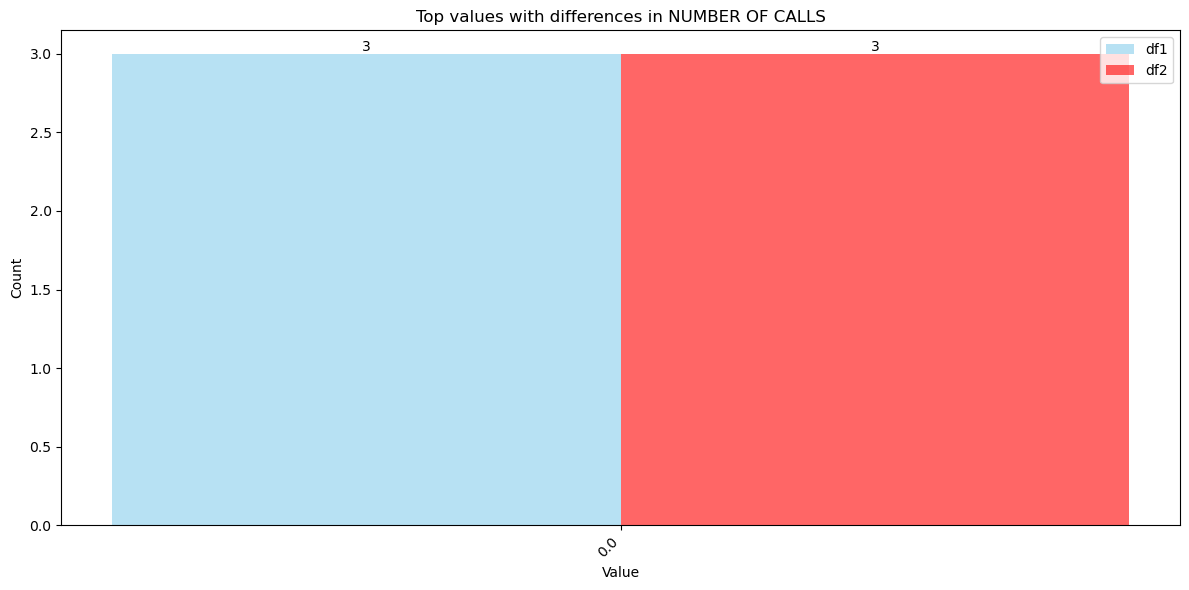

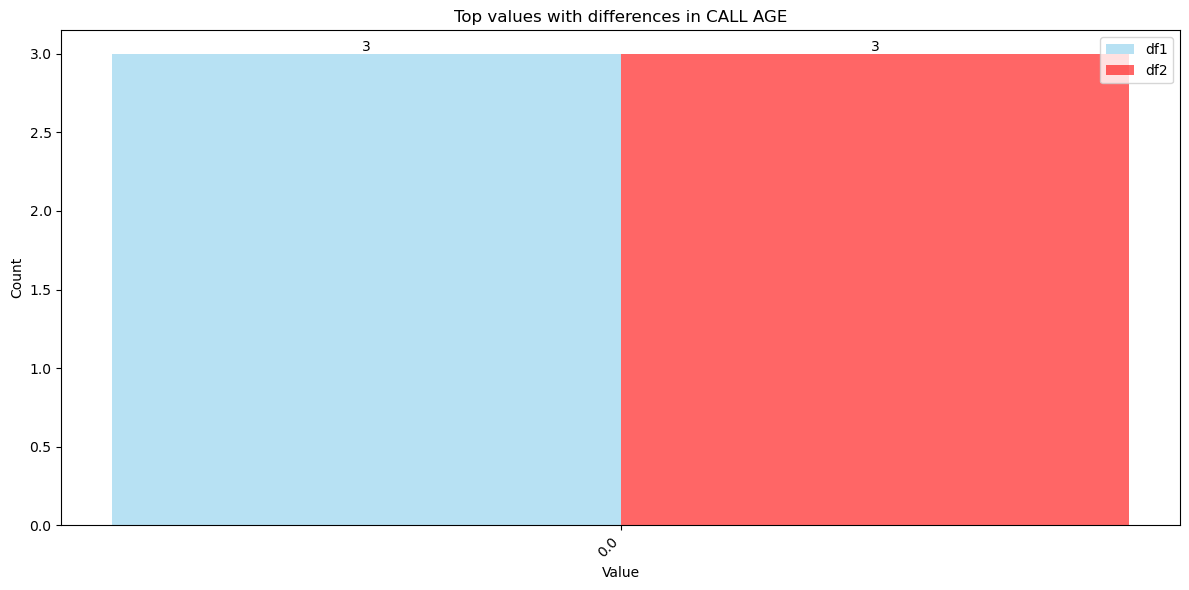

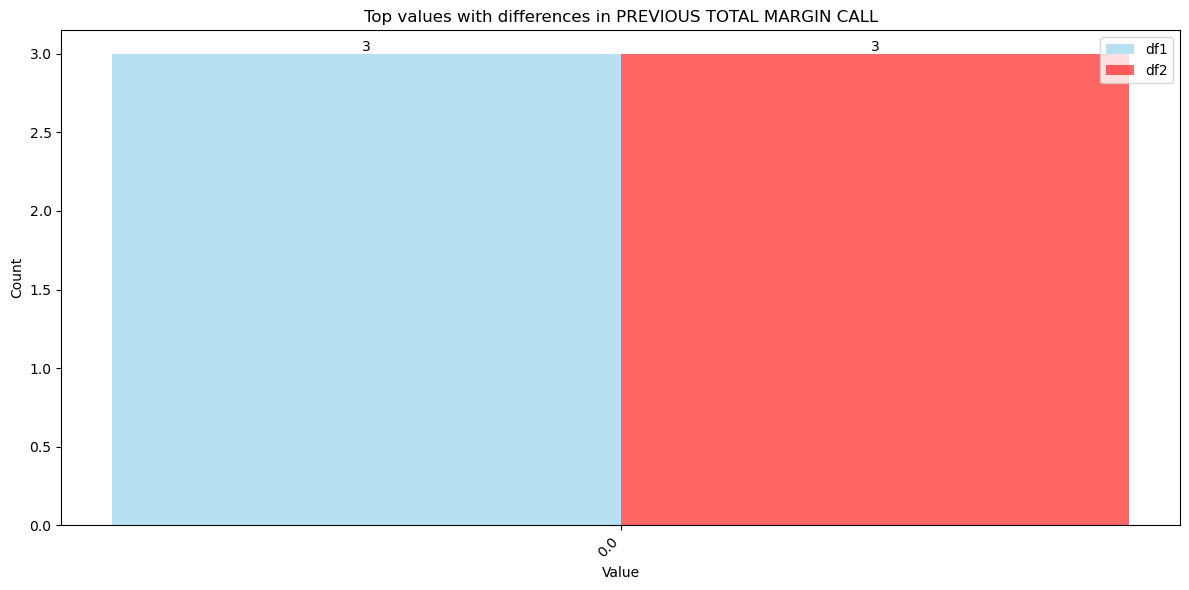

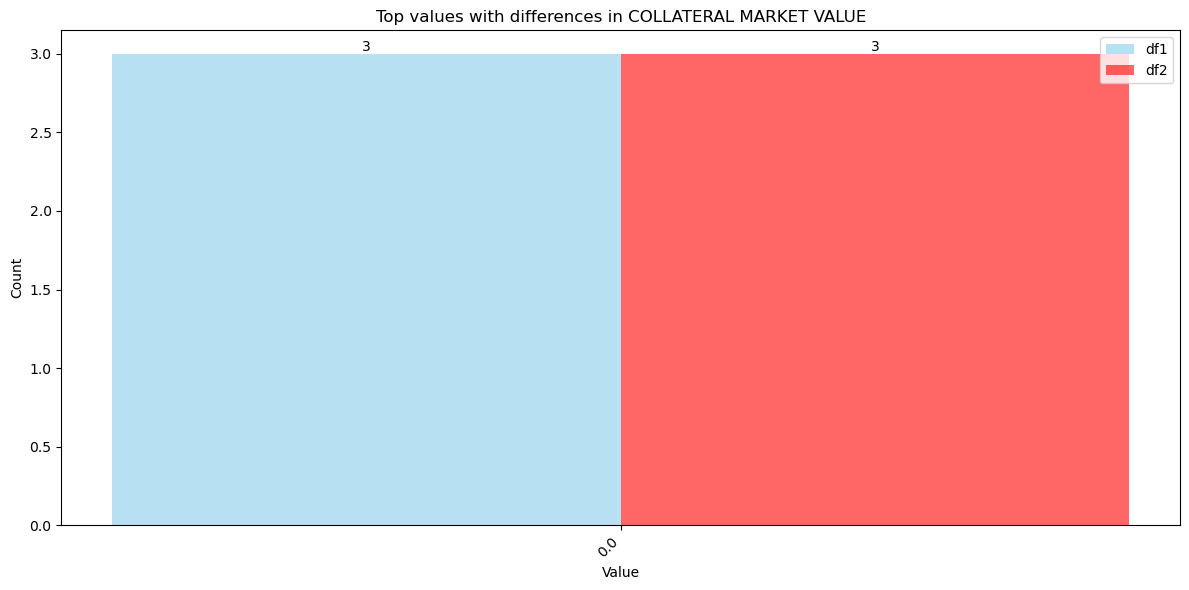

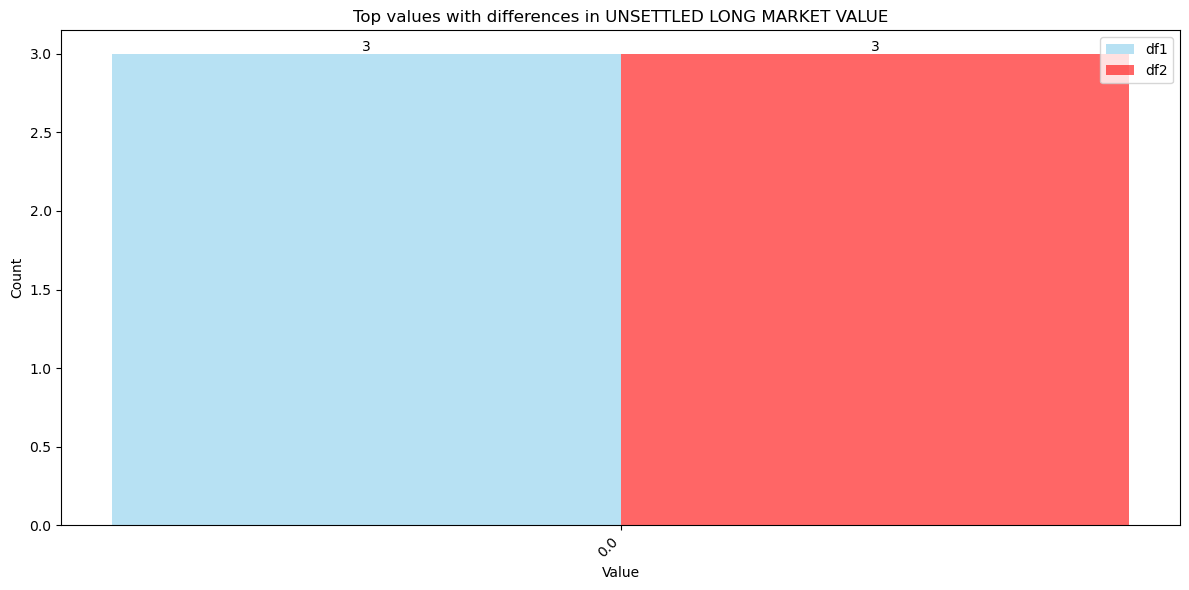

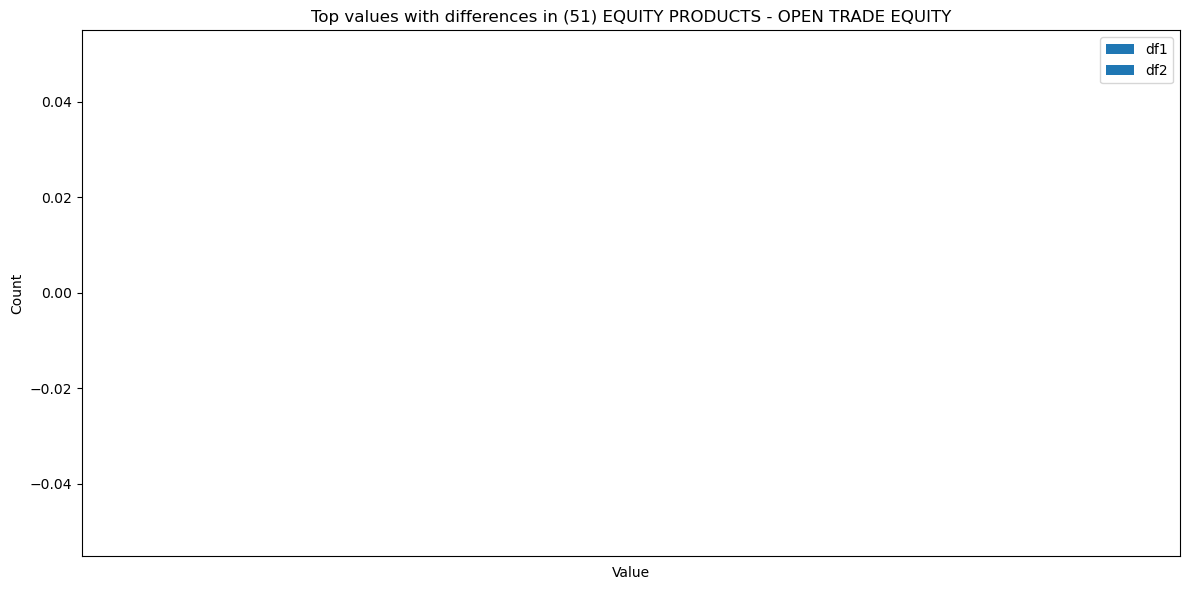

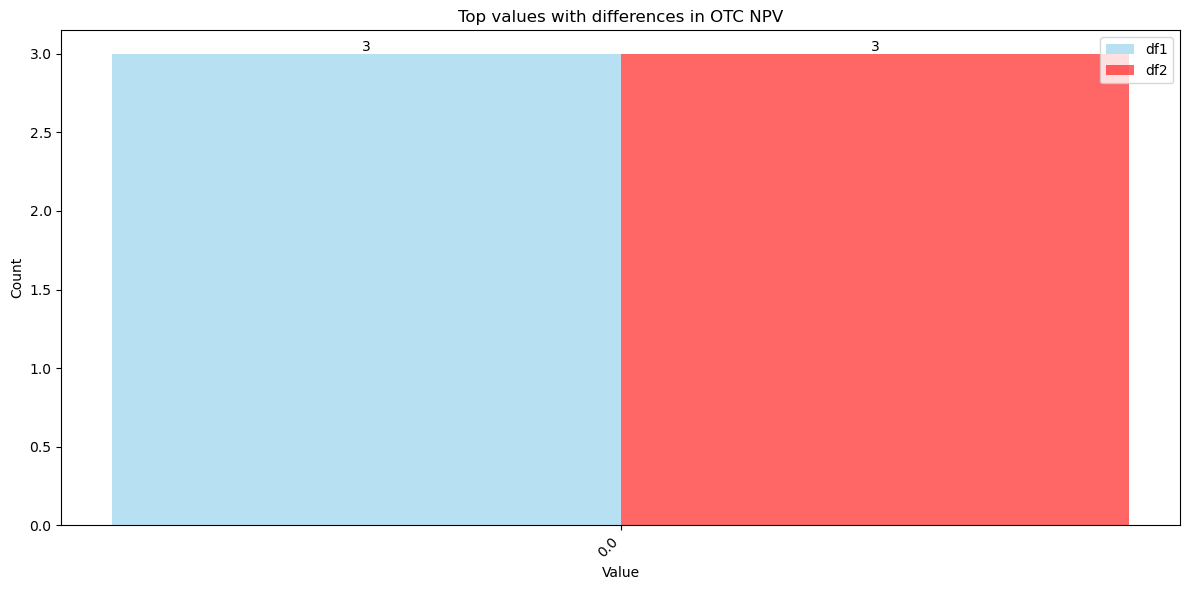

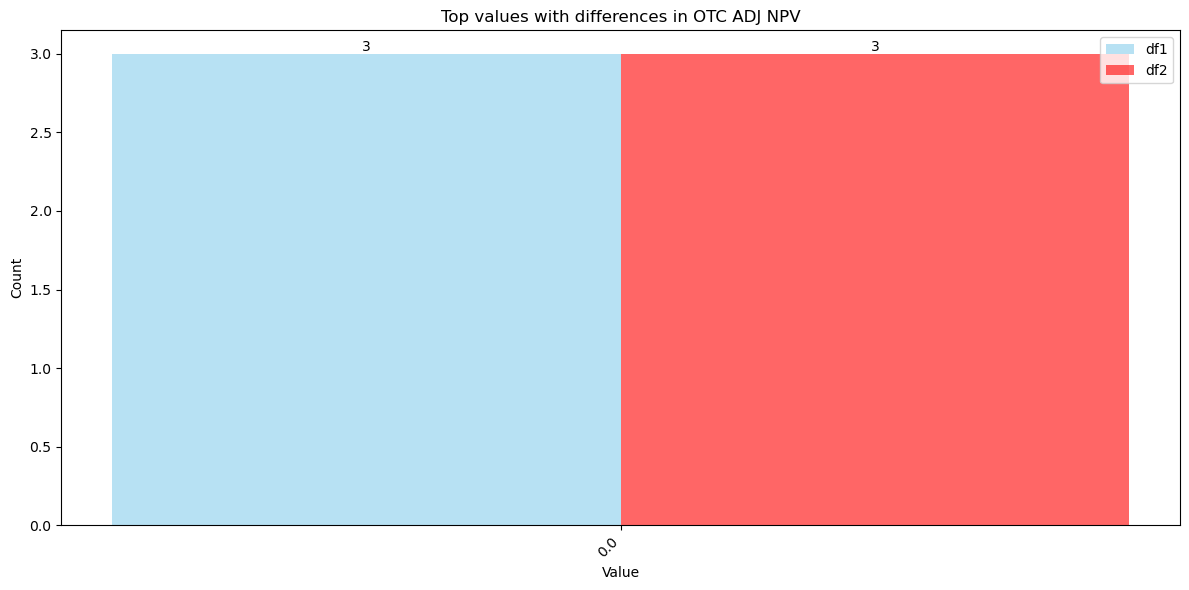

In [22]:
# 1. Plot rows with different values

visualize_differences(merged, diff_columns)


In [57]:
# 2. Analyze differences
diff_count = merged[merged[[f'diff_{col}' for col in diff_columns]].any(axis=1)].shape[0]  # Use shape to get the number of rows
total_rows = max(len(df1), len(df2))
diff_percentage = (diff_count / len(merged)) * 100

print(f"Total rows compared: {total_rows}")
print(f"Rows with differences: {diff_count}")
print(f"Difference percentage: {diff_percentage:.2f}%")

# print(f"Columns with differences: {diff_columns}")

Total rows compared: 21
Rows with differences: 48
Difference percentage: 80.00%


In [52]:
# 3. Detailed analysis of differences
for col in diff_columns:
    col_diff = merged[merged[f'diff_{col}'] == True]
    print(f"\nDifferences in {col}:")
    print(col_diff[[f"{col}_1", f"{col}_2"]])
    print(f"Total differences: {len(col_diff)}")


Differences in (51) EQUITY PRODUCTS - OPEN TRADE EQUITY:
Empty DataFrame
Columns: [(51) EQUITY PRODUCTS - OPEN TRADE EQUITY_1, (51) EQUITY PRODUCTS - OPEN TRADE EQUITY_2]
Index: []
Total differences: 0

Differences in ACCOUNT BALANCE:
    ACCOUNT BALANCE_1  ACCOUNT BALANCE_2
45                NaN                0.0
46                NaN                0.0
47                NaN                0.0
48         2435116.25                NaN
49         2435116.25                NaN
50         2435116.25                NaN
Total differences: 6

Differences in ACCOUNT TYPE:
   ACCOUNT TYPE_1 ACCOUNT TYPE_2
0              01              1
1              01             91
2              01             9Z
3              91              1
5              91             9Z
6              9Z              1
7              9Z             91
9              01              1
10             01             91
11             01             9Z
12             91              1
14             91             

In [56]:
import pandas as pd
import numpy as np



def compare_dataframes(df1, df2, keys):
    """
    Compare two DataFrames and find differences based on specified key columns.
    Consider NaN values as equal to each other.
    
    Parameters:
    df1, df2 : pandas DataFrames to compare
    keys : list of column names that uniquely identify rows
    
    Returns:
    pandas DataFrame with differences
    """
    # Ensure key columns exist in both DataFrames
    assert all(key in df1.columns and key in df2.columns for key in keys), "Key columns not found in both DataFrames"

    # Find common non-key columns
    common_columns = list(set(df1.columns) & set(df2.columns) - set(keys))

    # Merge DataFrames on key columns
    merged = pd.merge(df1, df2, on=keys, how='outer', suffixes=('_1', '_2'))

    differences = []

    # Compare values in common columns
    for col in common_columns:
        col1, col2 = f"{col}_1", f"{col}_2"
        
        # Check for differences, considering NaN values as equal
        mask = ~((merged[col1].isna() & merged[col2].isna()) | (merged[col1] == merged[col2]))
        
        diff_rows = merged[mask]
        
        for _, row in diff_rows.iterrows():
            differences.append({
                **{key: row[key] for key in keys},
                'Column': col,
                'DF1_Value': row[col1],
                'DF2_Value': row[col2]
            })

    # Check for columns present in only one DataFrame
    only_df1 = set(df1.columns) - set(df2.columns) - set(keys)
    only_df2 = set(df2.columns) - set(df1.columns) - set(keys)

    for col in only_df1:
        for _, row in df1.iterrows():
            if not pd.isna(row[col]):  # Only add if the value is not NaN
                differences.append({
                    **{key: row[key] for key in keys},
                    'Column': col,
                    'DF1_Value': row[col],
                    'DF2_Value': np.nan
                })

    for col in only_df2:
        for _, row in df2.iterrows():
            if not pd.isna(row[col]):  # Only add if the value is not NaN
                differences.append({
                    **{key: row[key] for key in keys},
                    'Column': col,
                    'DF1_Value': np.nan,
                    'DF2_Value': row[col]
                })

    # Create DataFrame from differences
    diff_df = pd.DataFrame(differences)

    # Sort the DataFrame for better readability
    sort_columns = keys + ['Column']
    diff_df = diff_df.sort_values(sort_columns).reset_index(drop=True)

    return diff_df

differences = compare_dataframes(df1, df2, KEYS)
print(differences.to_string())

      ACCOUNT                                Column                             DF1_Value            DF2_Value
0    UIS24100                          ACCOUNT TYPE                                    01                    1
1    UIS24100                          ACCOUNT TYPE                                    01                   91
2    UIS24100                          ACCOUNT TYPE                                    01                   9Z
3    UIS24100                          ACCOUNT TYPE                                    91                    1
4    UIS24100                          ACCOUNT TYPE                                    91                   9Z
5    UIS24100                          ACCOUNT TYPE                                    9Z                    1
6    UIS24100                          ACCOUNT TYPE                                    9Z                   91
7    UIS24100                            RECORD I D                                     M                    G
8

/home/jup/juputils.py:75: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[col] = df2[col].replace(r'^\s*$', np.nan, regex=True)
/home/jup/juputils.py:75: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[col] = df2[col].replace(r'^\s*$', np.nan, regex=True)
/tmp/ipykernel_407858/987505223.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  numeric_mask = df.applymap(is_numeric)


Merge by ID counts: _merge
left_only     21
right_only    21
Name: count, dtype: int64
Index(['RECORD I D', 'FIRM', 'OFFICE', 'ACCOUNT', 'ACCOUNT TYPE',
       'CURRENCY SYMBOL', 'SALESMAN', 'ACCOUNT BALANCE',
       'FUTURES OPEN TRADE EQUITY', 'LONG OPTION MARKET VALUE',
       'SHORT OPTION MARKET VALUE', 'LONG SECUR MARKET VALUE',
       'SHORT SECUR MARKET VALUE', 'TOTAL EQUITY', 'LIQUIDATING VALUE',
       'WITHDRAWABLE FUNDS', 'AVERAGE EQUITY', 'MONTH TO DATE COMMISSION',
       'FUTURES INITAL MARG REQ - TE MARGIN',
       'FUTURES MAINT MARGIN REQ - TE MARGIN', 'MARGIN EXCESS / DEFICIT - TE',
       'TOT OUTSTAND MARGN CALLS', 'EQUITIES INIT MRGN RQUIR',
       'TOTAL ACT. REQUIREMENTS', 'LONG OPT. OPN.TRD.EQUITY',
       'SHORT OPT OPN.TRD.EQUITY', 'MONTH TO DATE P&L', 'YEAR TO DATE P&L',
       'LAST ACTIVITY DATE', 'USD CONVERSION RATE', 'PREV FUT INIT MARG.REQ',
       'PREV FUT OPEN TRD EQUITY', 'PREV TOTAL EQUITY',
       'PREV LIQUIDATING VALUE', 'PREV ACCOUNT BALANCE',

KeyError: 'left_right'

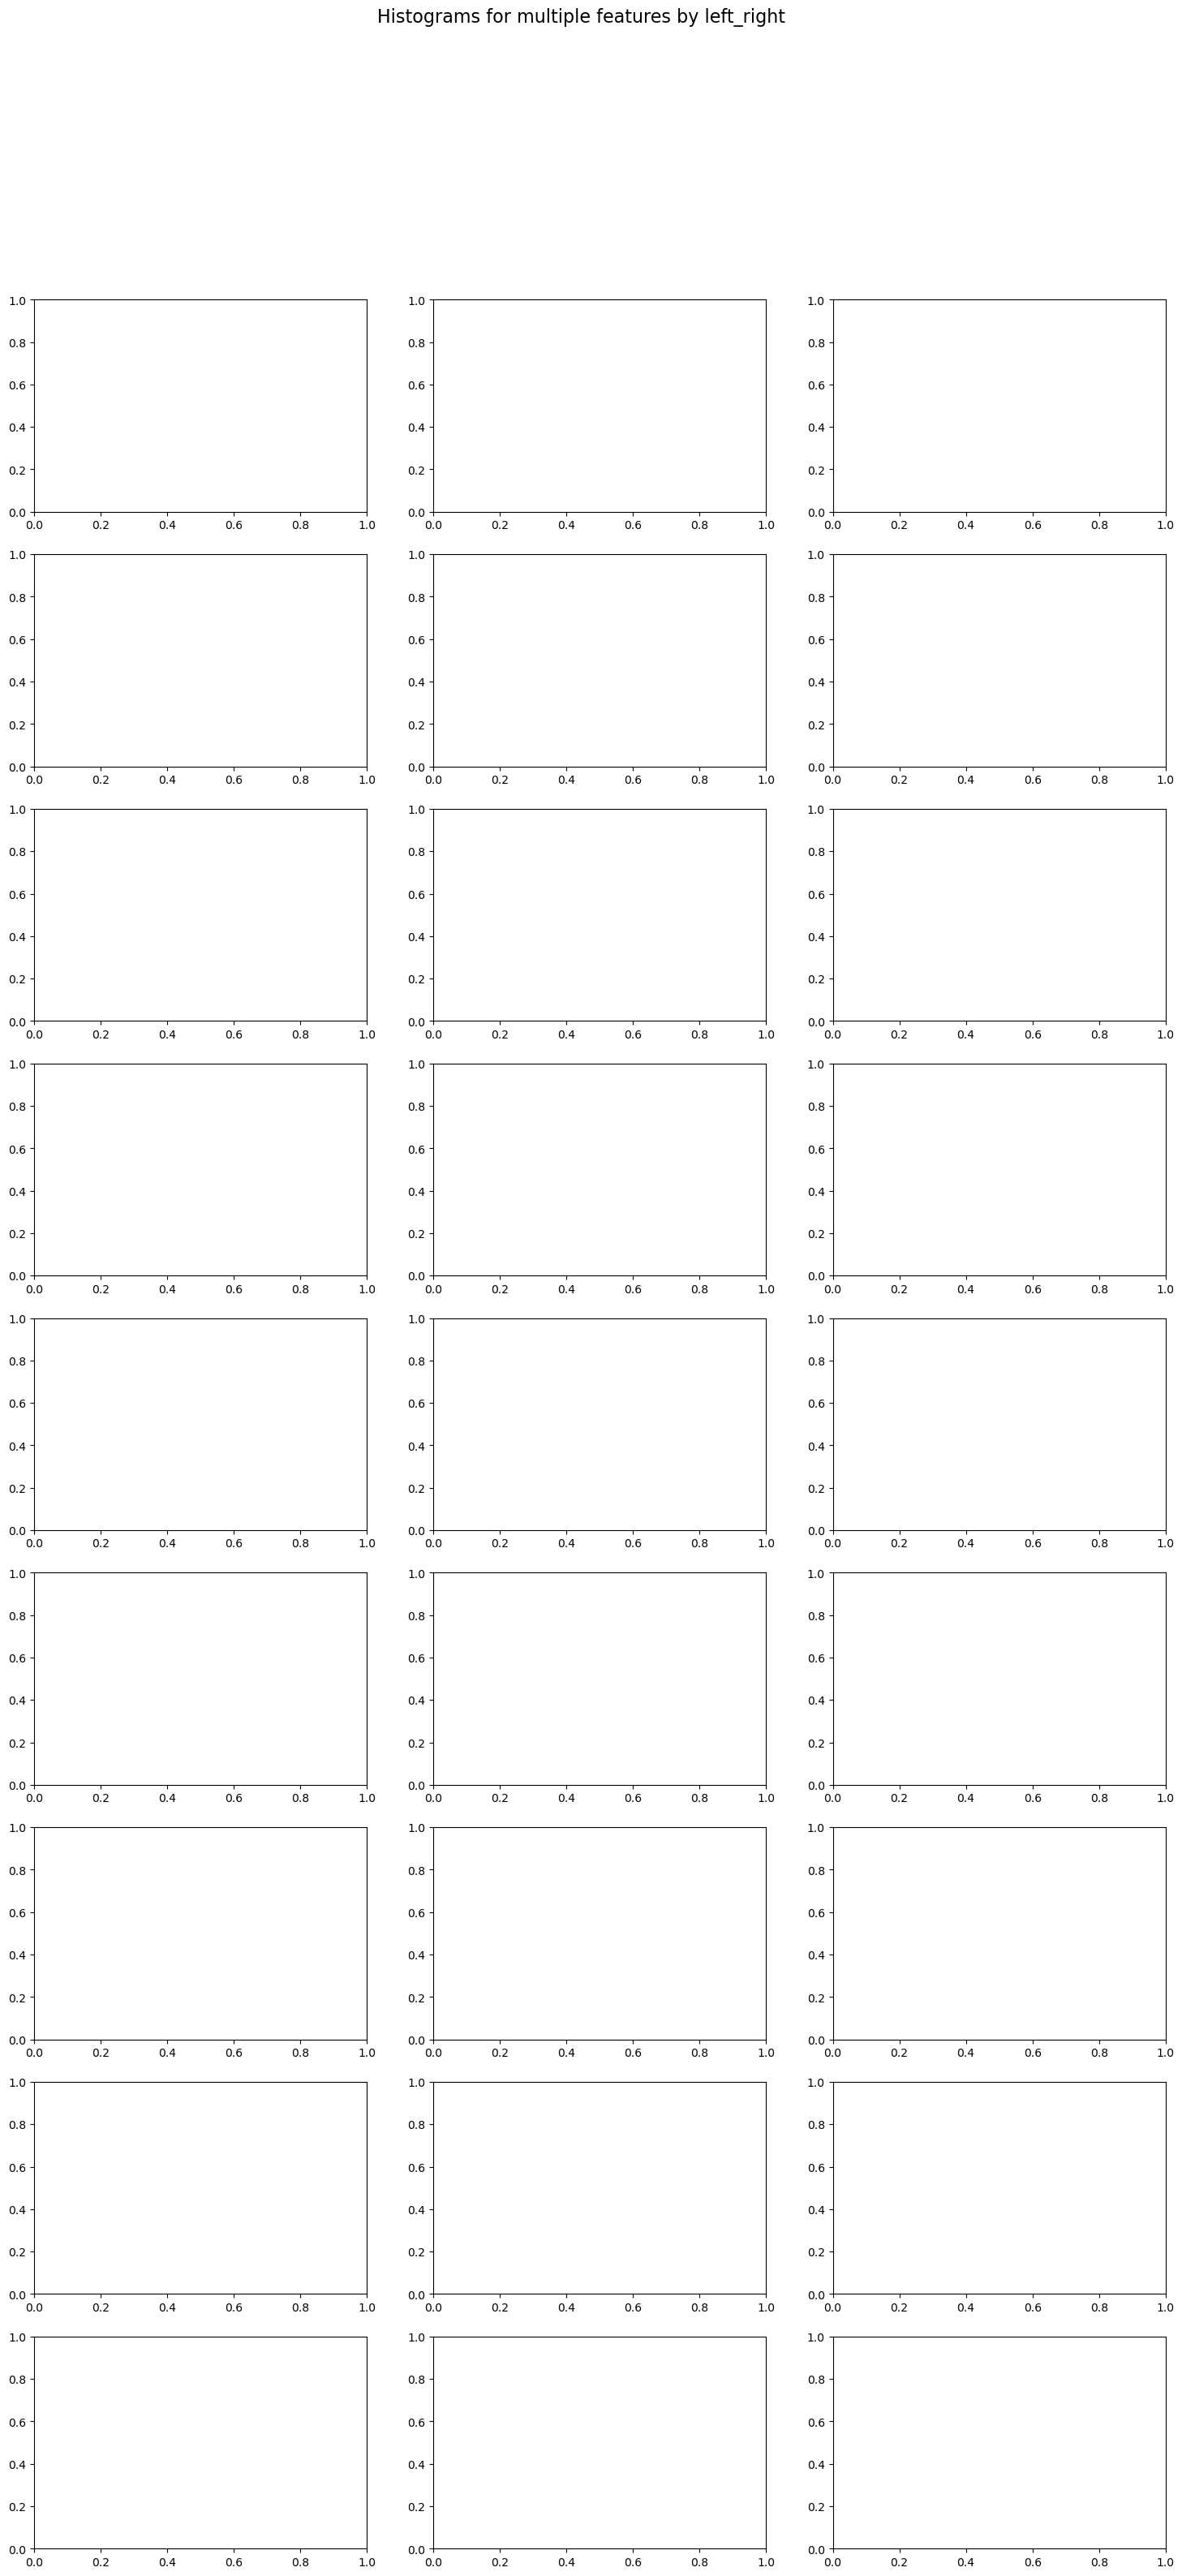

In [47]:
# --------------------------------------- Full Difference ------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tempfile
import os
# own
from mpoil.utils import xlsx_row_iterator
from juputils import histogram_multiple
from juputils import plot_top_n_by_binary
from juputils import cut_non_digit_underscore_hyphen
from juputils import read_uploads
from juputils import f1path, f2path


df1, df2, df = read_uploads(f1path,
                            f2path)
   
    
# - Count by ID
df2['_merge'] = 'right_only'
df1['_merge'] = 'left_only'
dfm = pd.concat([df1, df2], ignore_index=True)

print("Merge by ID counts:", dfm['_merge'].value_counts())

# ------------------------------ NUMBERS -------------------------------------------------------
# nums = ['totalActRespectExcluded', 'quantity', 'quantityMT', 'price', 'mtm', 'quantityBBLS', 'InvoiceAmountP', 'taxAmountP', 'paidAmountP', 'InvoiceAmountF', 'taxAmountF', 'paidAmountF', 'balancedue', 'totalAct', 'financingBank', 'letterOfCredit', 'lcIssuingBank', 'lcIssuingBankRef', 'lcAdvisingBank', 'lcAdvisingBankRef', 'lcAmount']
nums = []
# - Filter numbers
nums_rich = []
for n  in nums:
    dfm[n] = pd.to_numeric(dfm[n], errors='coerce')
    size = dfm[n].unique().size
    if size > 2 :
        nums_rich.append(n)
        
def is_numeric(val):
    try:
        float(val)
        return True
    except (ValueError, TypeError):
        return False

def identify_and_convert_numeric_columns(df, numeric_threshold=0.7, min_unique_values=3):
    # Check each value in the DataFrame
    numeric_mask = df.applymap(is_numeric)
    
    # Calculate percentage of numeric values in each column
    numeric_percentage = numeric_mask.mean()
    
    # Identify potentially numeric columns
    potential_numeric_cols = numeric_percentage[numeric_percentage >= numeric_threshold].index
    
    numeric_cols = []
    converted_df = df.copy()
    
    for col in potential_numeric_cols:
        # Convert to numeric, coercing errors to NaN
        converted = pd.to_numeric(df[col], errors='coerce')
        
        # Check if the column has enough unique values
        if converted.nunique() >= min_unique_values:
            converted_df[col] = converted
            numeric_cols.append(col)
    
    # Create a summary DataFrame
    summary = pd.DataFrame({
        'numeric_percentage': numeric_percentage,
        'unique_values': df.nunique(),
        'is_numeric': df.columns.isin(numeric_cols)
    })
    
    return converted_df, numeric_cols, summary

# Example usage
# df = your_dataframe
converted_dfm, numeric_columns, summary = identify_and_convert_numeric_columns(dfm)
print(converted_dfm.columns)        
# - Plot numbers
histogram_multiple(converted_dfm,
                   feature_mains=numeric_columns,
                   feature_binary='left_right',
                   bins=30,
                   density=True,
                   label_left=cut_non_digit_underscore_hyphen(os.path.basename(f1path)),
                   label_right=cut_non_digit_underscore_hyphen(os.path.basename(f2path)),
                   image_save=None)


In [ ]:
import os
from juputils import plot_top_n_by_binary
from juputils import cut_non_digit_underscore_hyphen
# --------------------------------- STRINGS --------------------------------------------------------
# - Plot strings
# 
s_cols = ['Product', 'tradeState', 'tradeType', 'tradeID', 'currency', 'companyShortName', 'books', 'Shipment Strategy ID', 'Shipment Strategy', 'vessel', 'counterparty', 'quantityUoM', 'ActualEstimated', 'incoterms', 'pricingMonth', 'pricingFormula', 'PricingCurrency', 'location', 'broker', 'costcomment', 'company', 'titleevent', 'conversion', 'type', 'provisonalPaymentTerms', 'bankAccountP', 'invoiceVouchedByP', 'invoiceStateP', 'finalPaymentTermsF', 'bankAccountF', 'invoiceVouchedByF', 'invoiceStateF', 'vatGST', 'creditType', 'strategy', 'costCreatedBy', 'trader', 'hierarchies', 'Full Hierarchies', 'Default Trader']
plot_top_n_by_binary(df, s_cols, 'left_right', n=5,
                     label_left=cut_non_digit_underscore_hyphen(os.path.basename(f1path)),
                     label_right=cut_non_digit_underscore_hyphen(os.path.basename(f2path)),
                     image_save=None)

In [ ]:
# - totalActRespectExcluded wihtout small values and outliers
tare = dfm['totalActRespectExcluded']
tare1 = tare[tare.between(tare.quantile(0.02), tare.quantile(0.98))]
df1 = df.copy()
df1['totalActRespectExcluded'] = pd.concat([tare1[(tare1 > 3000)],tare1[(tare1 < -3000)]])
histogram_multiple(df1,
                   feature_mains=['totalActRespectExcluded'],
                   feature_binary='left_right',
                   bins=40,
                   density=True,
                   label_left=cut_non_digit_underscore_hyphen(os.path.basename(f1path)),
                   label_right=cut_non_digit_underscore_hyphen(os.path.basename(f2path)),
                   image_save=None)